In [3]:
# Импорт библиотек
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
import graphviz
import shap
from sklearn.tree import export_text
import matplotlib.pyplot as plt


# Установка стилей
plt.style.use('ggplot')
sns.set_style("whitegrid")
%matplotlib inline

# 1. Загрузка данных
print("1. Загрузка данных...")
PATH = 'wine+quality/'
TRAIN_PATH = PATH + 'winequality-red.csv'
TEST_PATH = PATH + 'winequality-white.csv'

red_wine = pd.read_csv(TRAIN_PATH, sep=';')
white_wine = pd.read_csv(TEST_PATH, sep=';')

1. Загрузка данных...


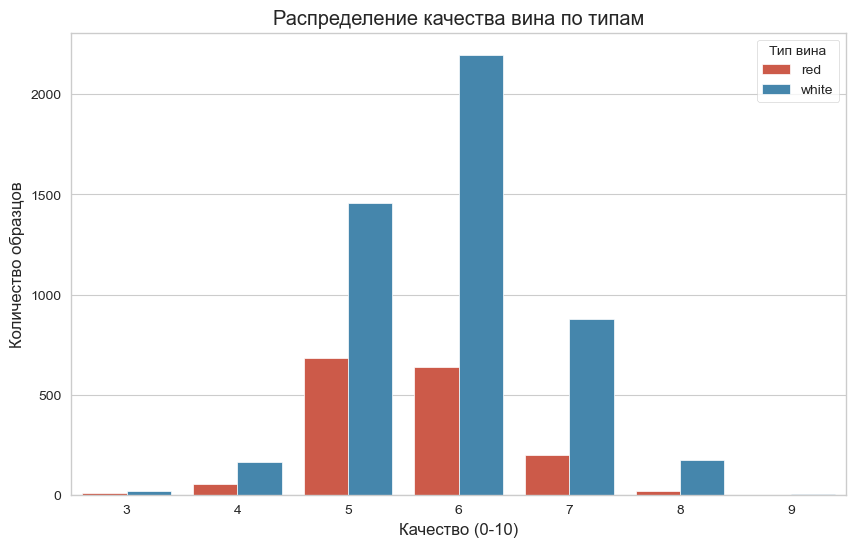

In [4]:
# Объединение датасетов

# Добавление меток типа вина
red_wine['wine_type'] = 'red'
white_wine['wine_type'] = 'white'

wines = pd.concat([red_wine, white_wine], ignore_index=True)
# Функция для визуализации
def plot_quality_distribution(data):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='quality', hue='wine_type', data=data)
    plt.title('Распределение качества вина по типам')
    plt.xlabel('Качество (0-10)')
    plt.ylabel('Количество образцов')
    plt.legend(title='Тип вина')
    plt.show()

# Вызов функции
plot_quality_distribution(wines)

In [5]:
# Предварительный анализ данных
print("\nПервые 5 строк данных:")
display(wines.head())

print("\nИнформация о данных:")
print(wines.info())

print("\nОписательная статистика:")
display(wines.describe())


Первые 5 строк данных:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None

Описательная статистика:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


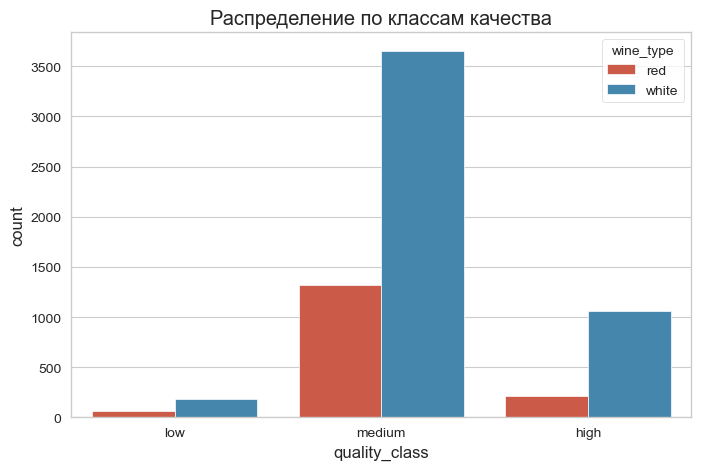

In [6]:
# Разделение на 3 класса качества
def classify_quality(quality):
    if quality <= 4:
        return 'low'
    elif 5 <= quality <= 6:
        return 'medium'
    else:
        return 'high'

wines['quality_class'] = wines['quality'].apply(classify_quality)

# Визуализация классов
plt.figure(figsize=(8, 5))
sns.countplot(x='quality_class', hue='wine_type', data=wines, 
             order=['low', 'medium', 'high'])
plt.title('Распределение по классам качества')
plt.show()

In [7]:

print(f"Загружено {len(wines)} образцов")

# 2. Предобработка данных
print("\n2. Предобработка данных...")
wines['quality_class'] = pd.cut(wines['quality'],
                              bins=[0, 4, 6, 10],
                              labels=['low', 'medium', 'high'])

X = wines.drop(['quality', 'quality_class', 'wine_type'], axis=1)
y = wines['quality_class']

# Кодирование классов
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Загружено 6497 образцов

2. Предобработка данных...


In [8]:

# 3. Обучение Random Forest
print("\n3. Обучение Random Forest...")
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
print(f"Лучшие параметры Random Forest: {grid.best_params_}")



3. Обучение Random Forest...
Лучшие параметры Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}



Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Анализ важности признаков:


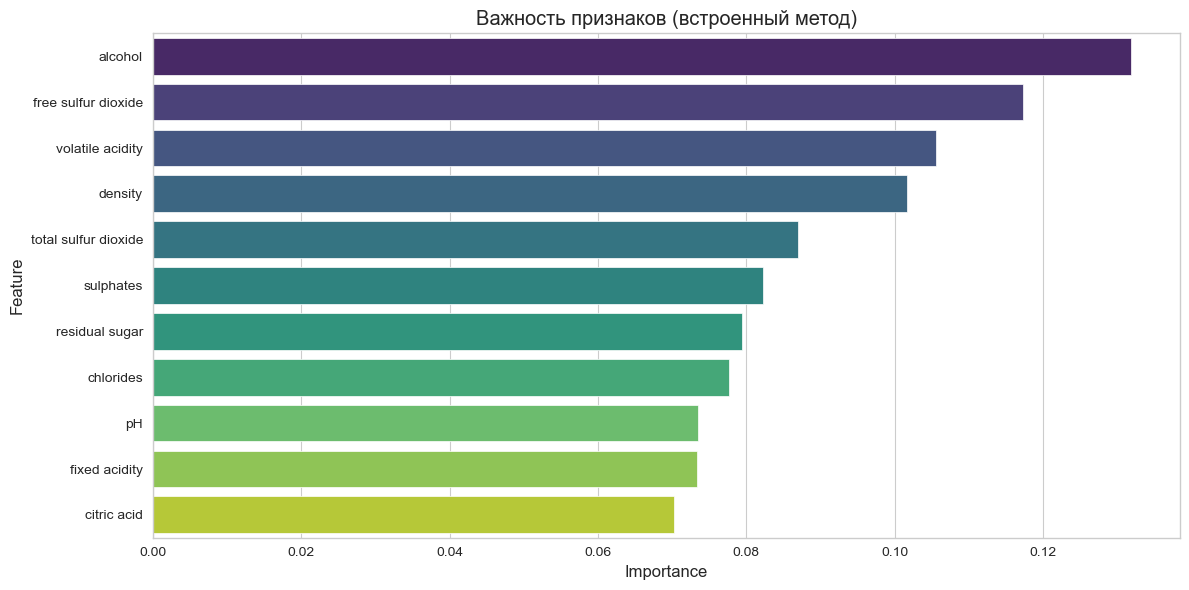

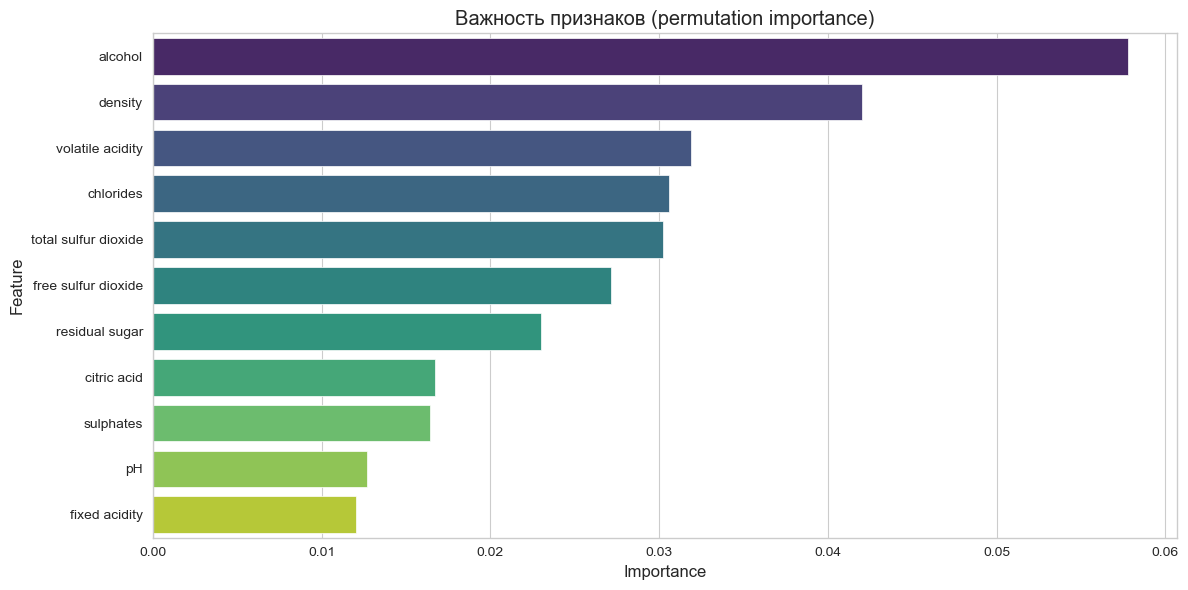

In [9]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_clf = GridSearchCV(rf_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_clf.fit(X_train_scaled, y_train)

best_clf = grid_clf.best_estimator_
print(f"\nЛучшие параметры: {grid_clf.best_params_}")
# Полный анализ важности признаков
print("\nАнализ важности признаков:")

# 1. Встроенная важность признаков
importances = best_clf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Важность признаков (встроенный метод)')
plt.tight_layout()
plt.show()

# 2. Permutation Importance
from sklearn.inspection import permutation_importance
result = permutation_importance(
    best_clf, X_test_scaled, y_test, n_repeats=10, random_state=42
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=perm_importance, palette='viridis')
plt.title('Важность признаков (permutation importance)')
plt.tight_layout()
plt.show()



4. Визуализация одного дерева из Random Forest...
Текстовое представление дерева:

|--- free sulfur dioxide <= -1.06
|   |--- density <= 0.54
|   |   |--- volatile acidity <= 0.77
|   |   |   |--- chlorides <= 0.17
|   |   |   |   |--- density <= -1.78
|   |   |   |   |   |--- density <= -1.82
|   |   |   |   |   |   |--- class: medium
|   |   |   |   |   |--- density >  -1.82
|   |   |   |   |   |   |--- class: high
|   |   |   |   |--- density >  -1.78
|   |   |   |   |   |--- residual sugar <= 0.18
|   |   |   |   |   |   |--- total sulfur dioxide <= -1.50
|   |   |   |   |   |   |   |--- residual sugar <= 0.03
|   |   |   |   |   |   |   |   |--- residual sugar <= -0.74
|   |   |   |   |   |   |   |   |   |--- class: medium
|   |   |   |   |   |   |   |   |--- residual sugar >  -0.74
|   |   |   |   |   |   |   |   |   |--- alcohol <= -0.03
|   |   |   |   |   |   |   |   |   |   |--- class: medium
|   |   |   |   |   |   |   |   |   |--- alcohol >  -0.03
|   |   |   |   |   |   |

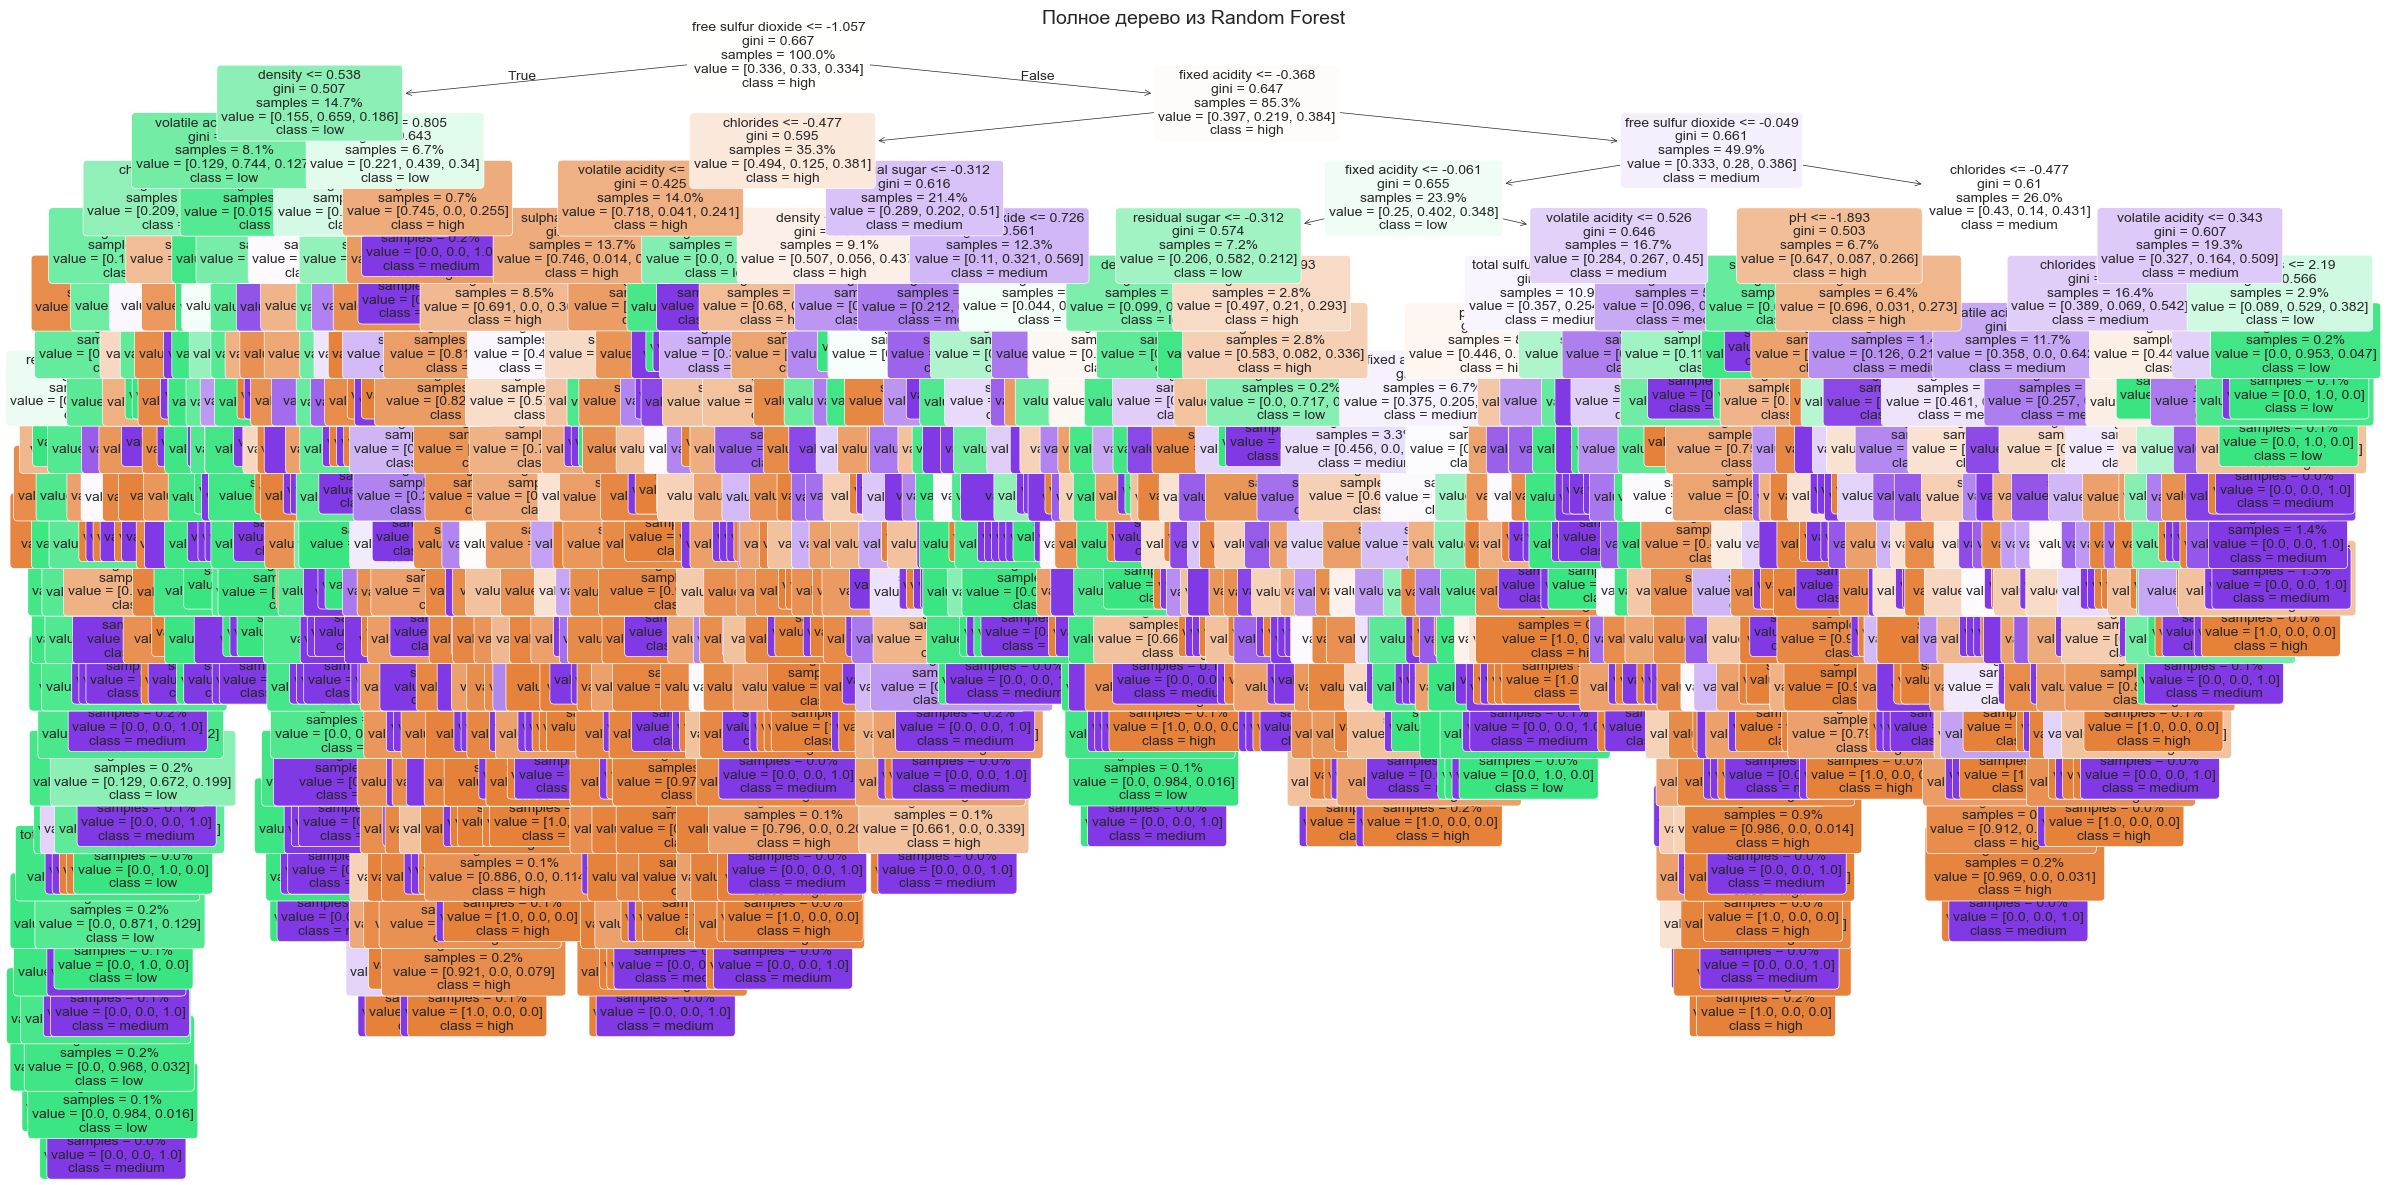

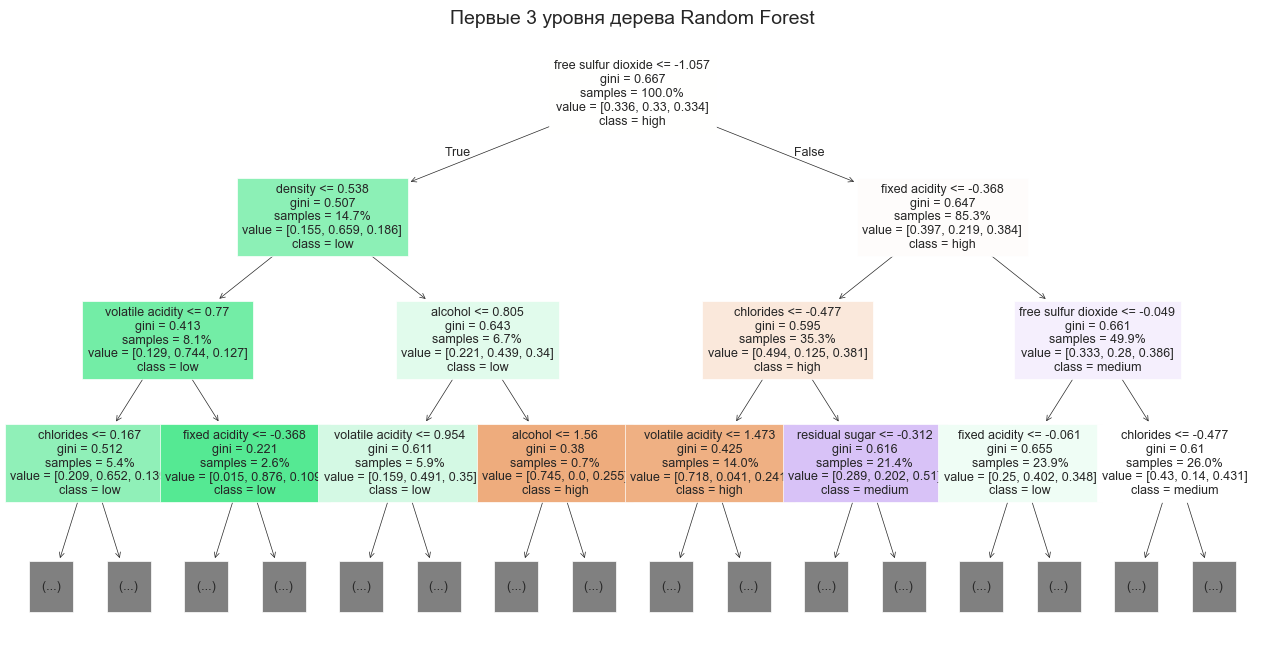

In [10]:
# 4. Визуализация одного полного дерева Random Forest
print("\n4. Визуализация одного дерева из Random Forest...")

# Выбираем первое дерево из ансамбля
single_tree = best_rf.estimators_[0]

# Вариант 1: Текстовое представление (работает всегда)
tree_rules = export_text(single_tree, 
                        feature_names=list(X.columns),
                        class_names=list(le.classes_))
print("Текстовое представление дерева:\n")
print(tree_rules[:2000] + "...")  # Выводим первые 2000 символов

# Вариант 2: Графическое представление (если установлен graphviz)
try:
    # Визуализация с увеличенным размером и полной глубиной
    plt.figure(figsize=(24, 12))
    tree.plot_tree(single_tree,
                 feature_names=X.columns,
                 class_names=le.classes_,
                 filled=True,
                 rounded=True,
                 proportion=True,
                 fontsize=10,
                 max_depth=None)  # Без ограничения глубины
    
    plt.title("Полное дерево из Random Forest", fontsize=14)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print("\nНе удалось построить графическое дерево. Установите graphviz:")
    print("1. Скачайте с https://graphviz.org/download/")
    print("2. Добавьте в PATH (или установите через conda: conda install python-graphviz)")
    print(f"Ошибка: {e}")

# Вариант 3: Альтернативная визуализация важных ветвей
plt.figure(figsize=(16, 8))
tree.plot_tree(single_tree,
              feature_names=X.columns,
              class_names=le.classes_,
              filled=True,
              max_depth=3,  # Показываем первые 3 уровня для читаемости
              proportion=True,
              fontsize=9)
plt.title("Первые 3 уровня дерева Random Forest", fontsize=14)
plt.show()


5. Анализ важности признаков в Random Forest...


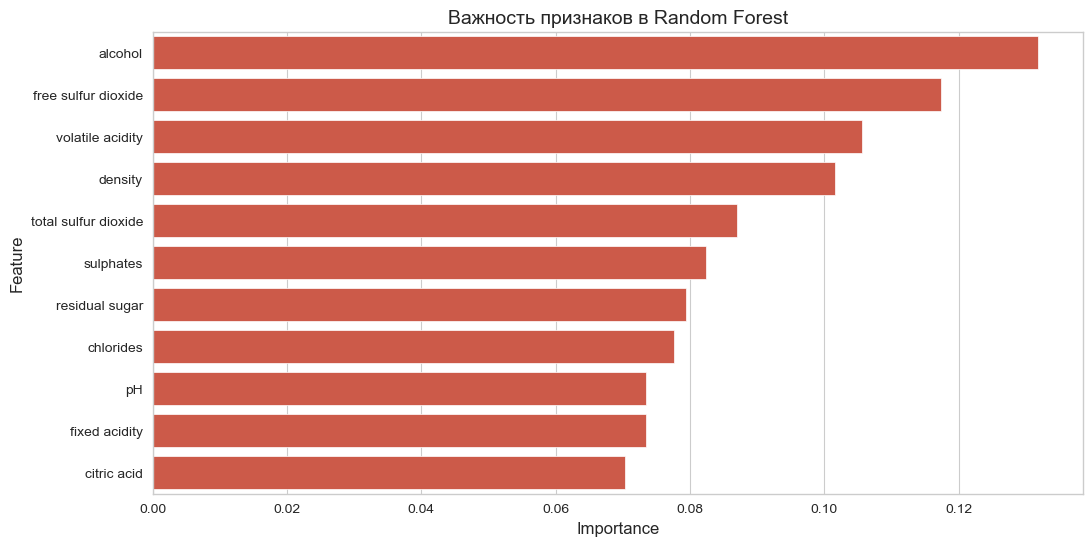

In [11]:

# 5. Анализ важности признаков
print("\n5. Анализ важности признаков в Random Forest...")

# Важность признаков
importances = best_rf.feature_importances_
feature_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp = feature_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title("Важность признаков в Random Forest", fontsize=14)
plt.show()




Вычисление SHAP значений для Random Forest...

Вариант 1: Интерактивная визуализация SHAP (использует JavaScript)


<Figure size 640x480 with 0 Axes>

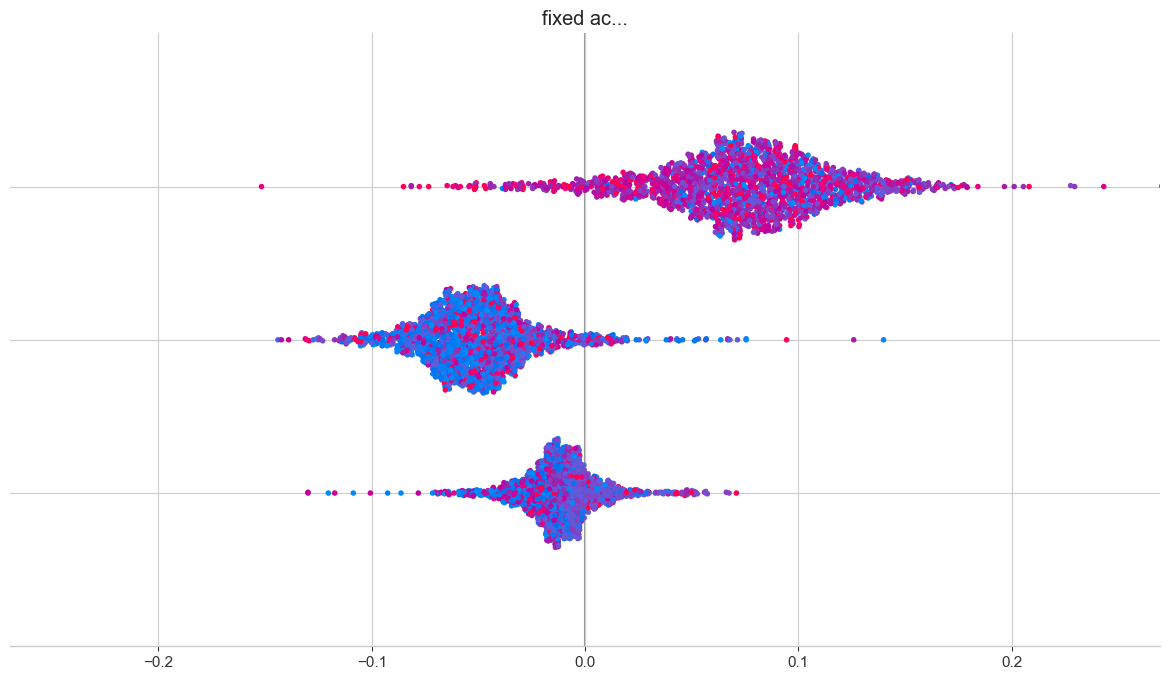


Вариант 2: Статичная визуализация SHAP


<Figure size 1200x600 with 0 Axes>

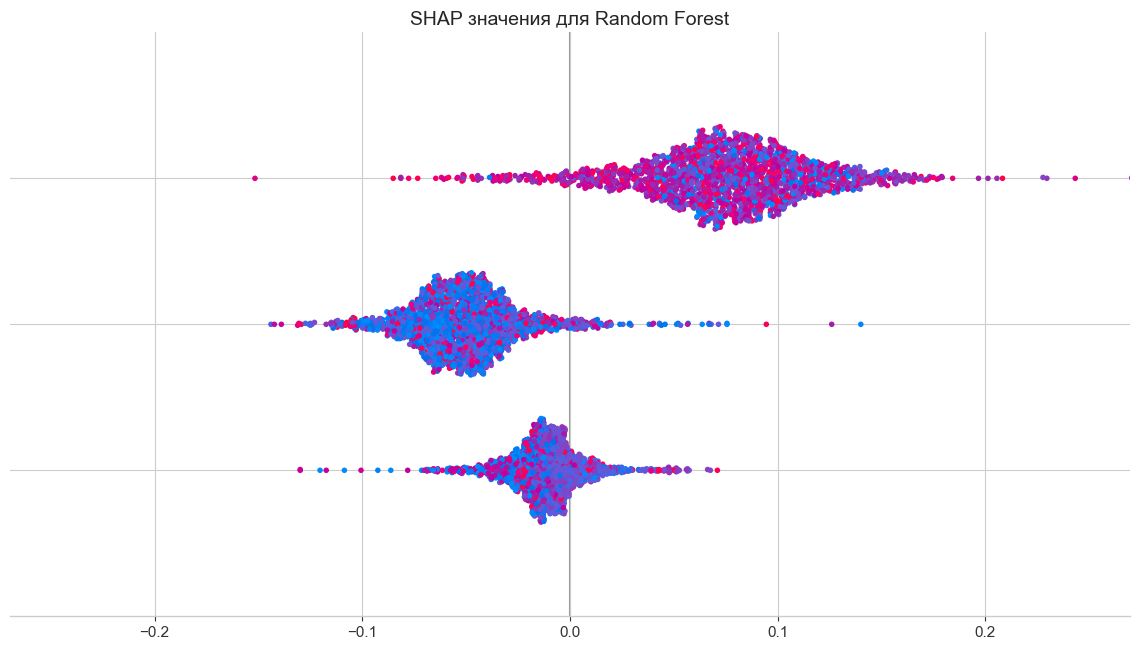

In [12]:

shap.initjs()  # Инициализация JavaScript-визуализаций

# Вычисление SHAP значений
print("\nВычисление SHAP значений для Random Forest...")
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Вариант 1: Интерактивная визуализация (лучше для Jupyter)
print("\nВариант 1: Интерактивная визуализация SHAP (использует JavaScript)")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, class_names=list(le.classes_))

# Вариант 2: Статичная визуализация с matplotlib
print("\nВариант 2: Статичная визуализация SHAP")
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, class_names=list(le.classes_), show=False)
plt.title("SHAP значения для Random Forest", fontsize=14)
plt.tight_layout()
plt.show()




6. Детальный анализ признаков...
Топ-9 важных признака: ['alcohol' 'free sulfur dioxide' 'volatile acidity' 'density'
 'total sulfur dioxide' 'sulphates' 'residual sugar' 'chlorides' 'pH']


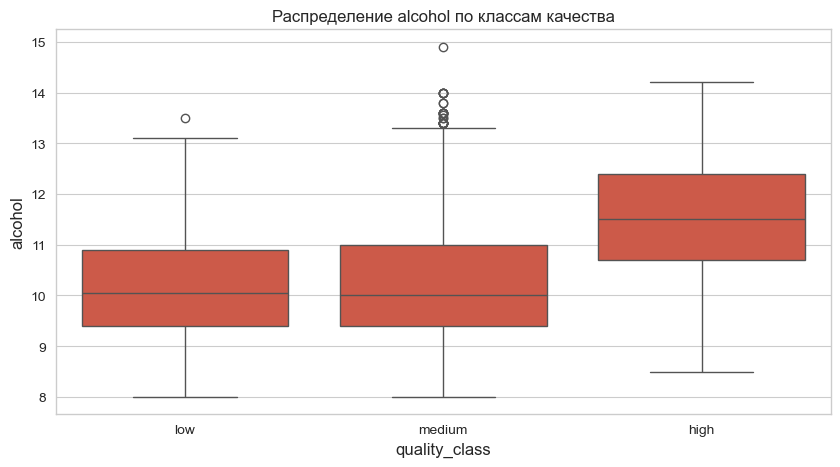

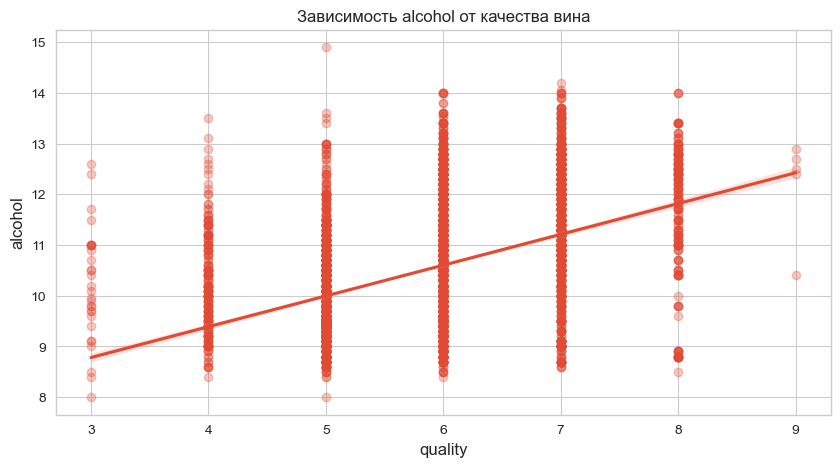

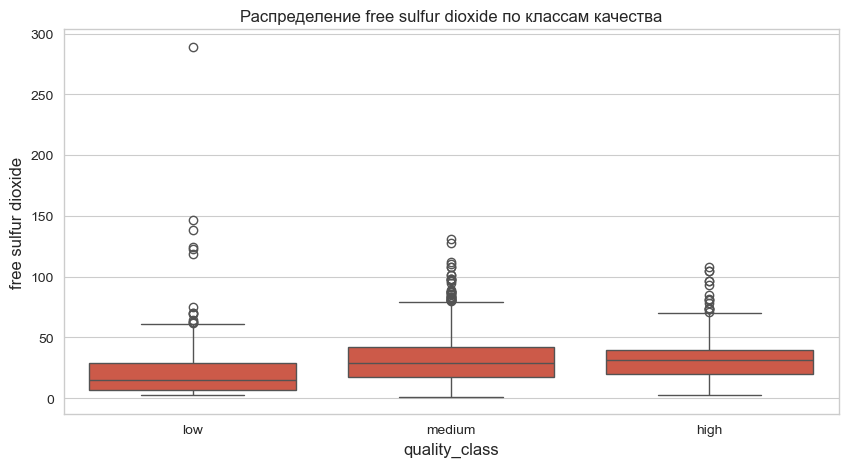

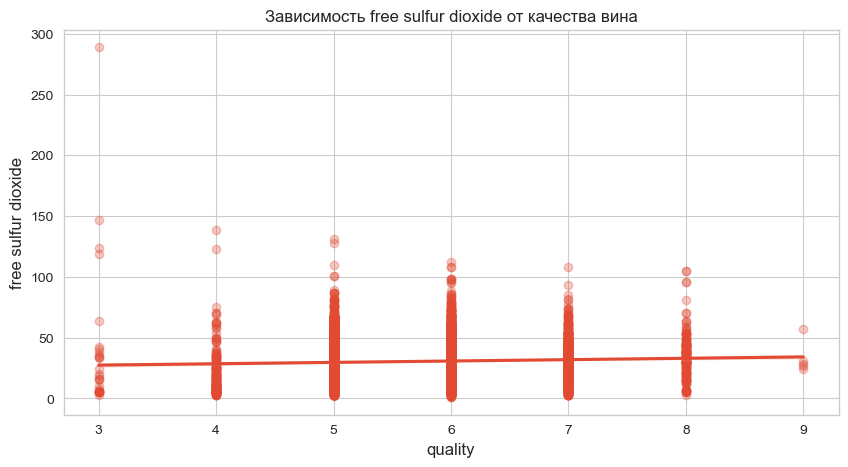

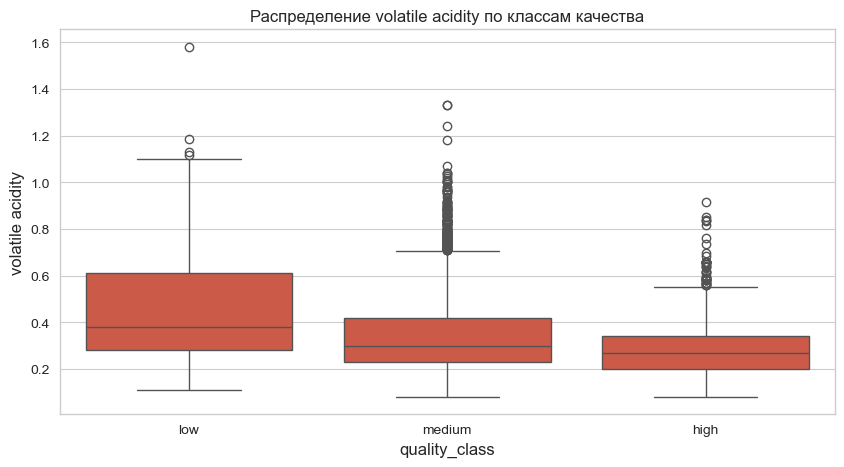

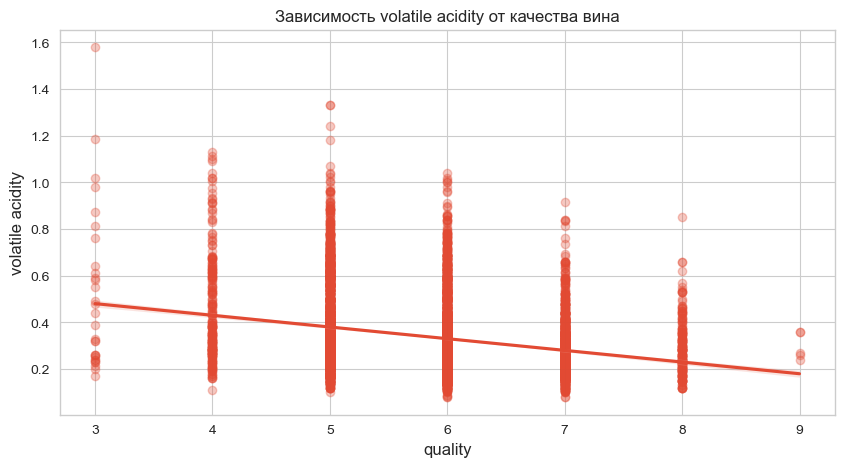

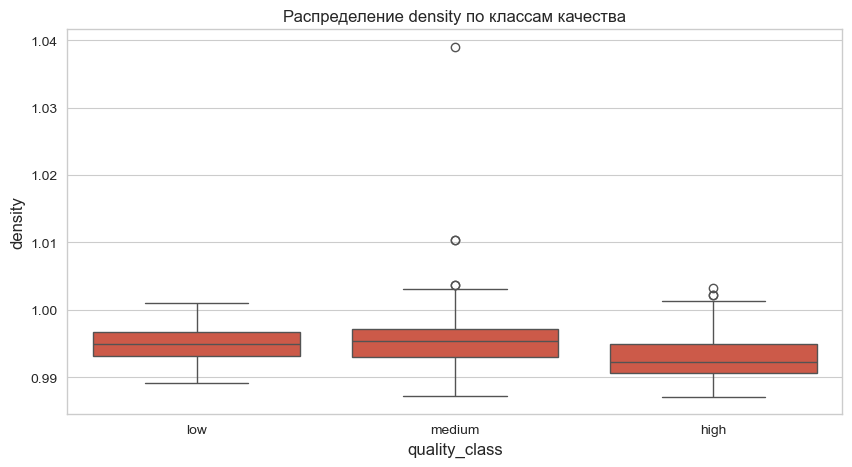

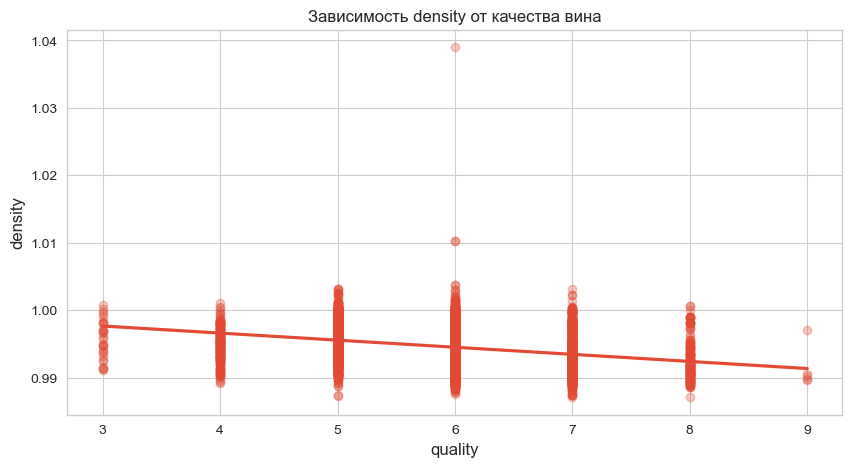

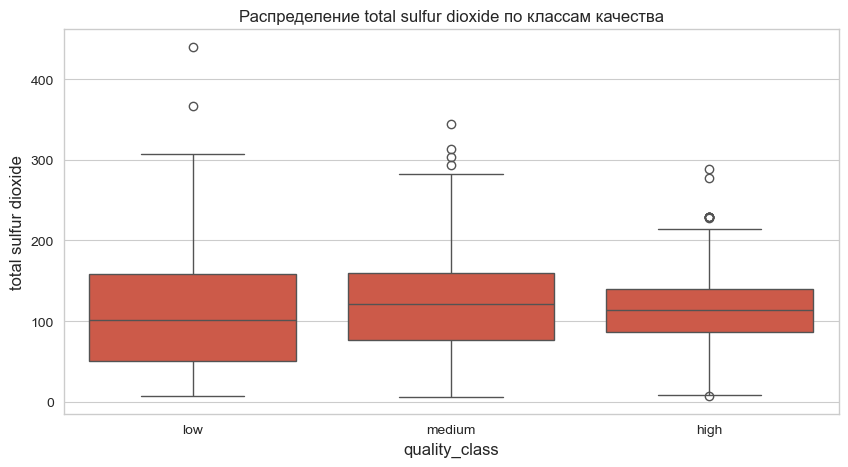

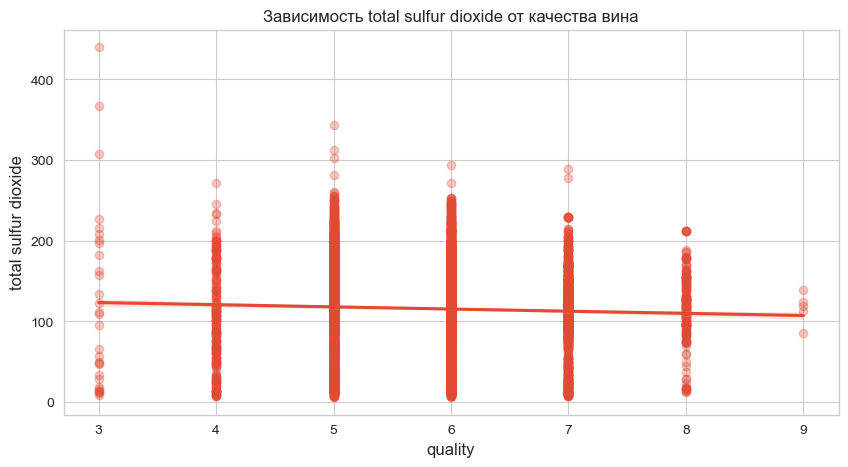

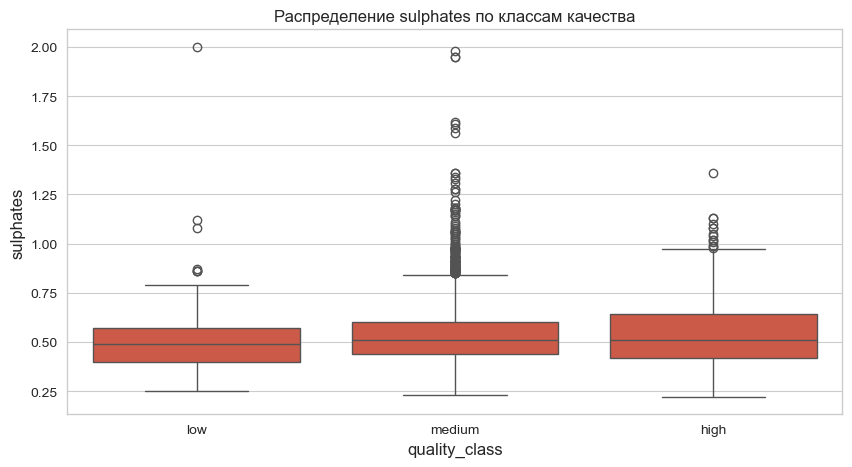

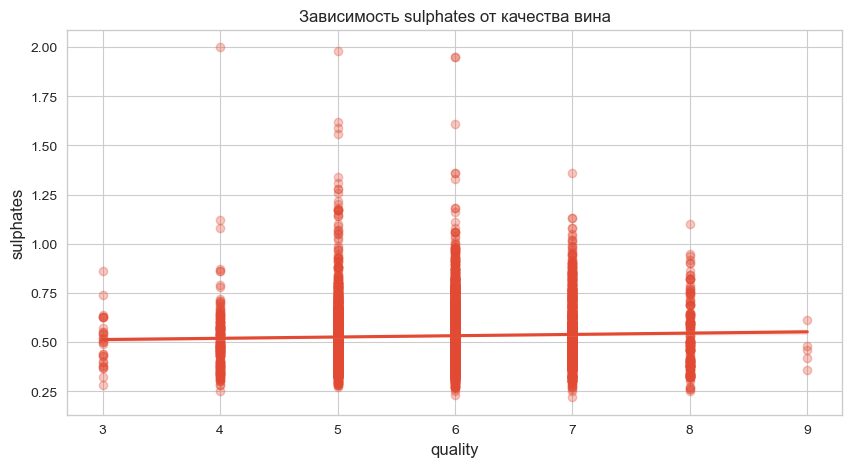

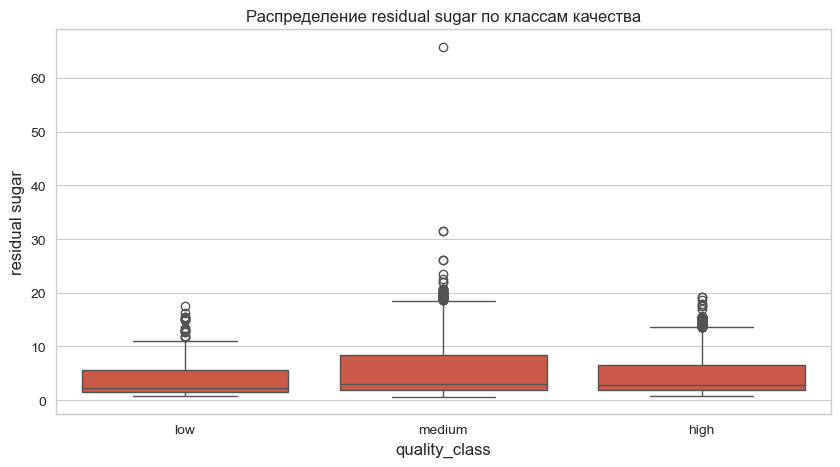

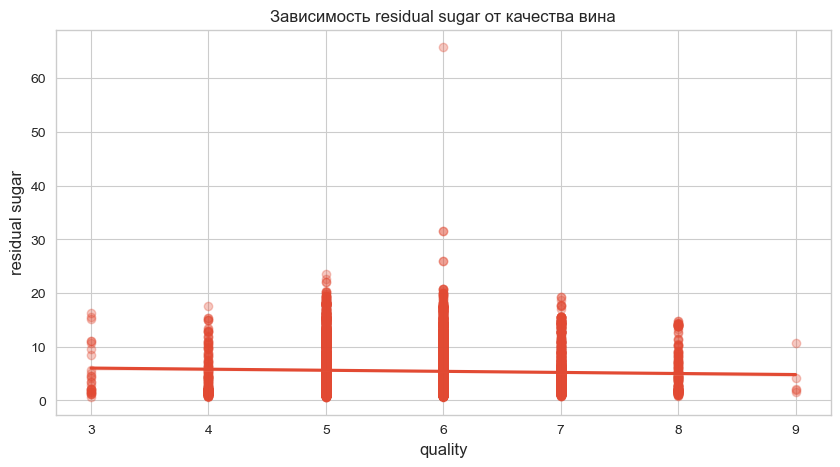

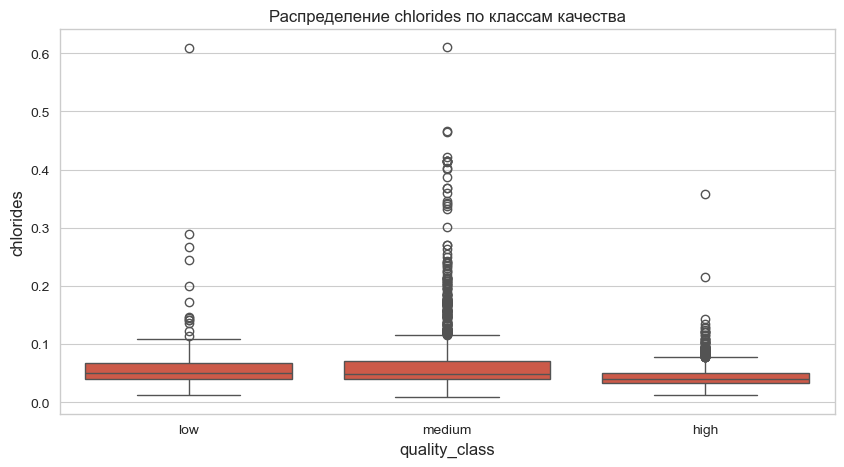

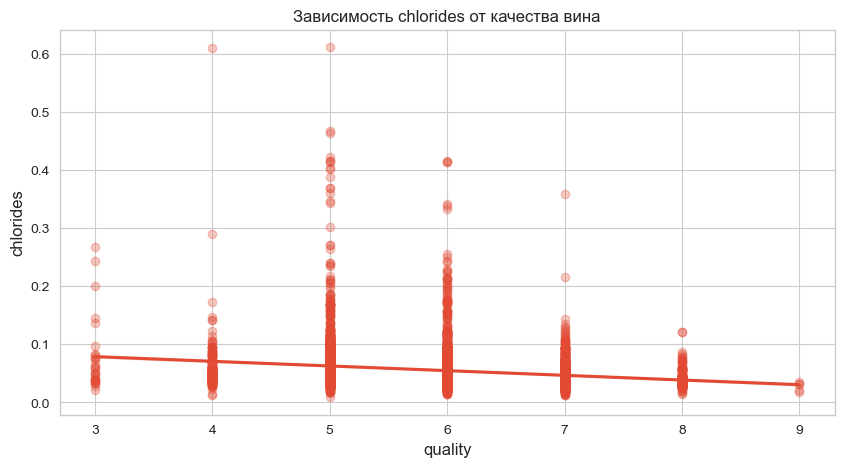

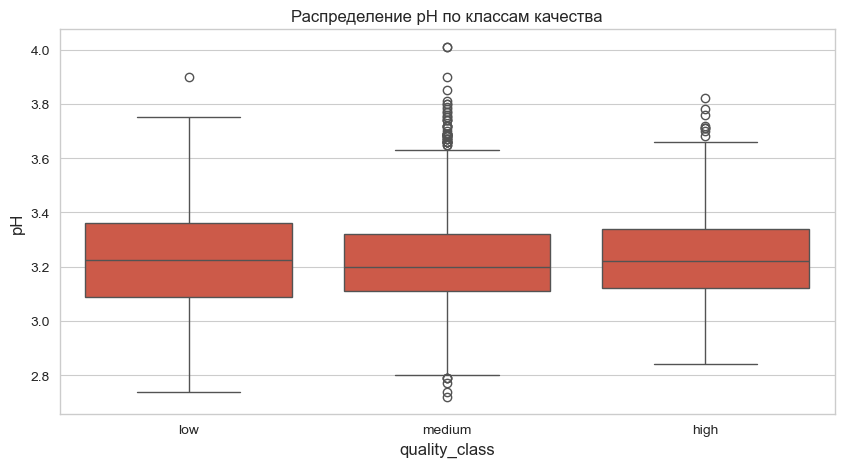

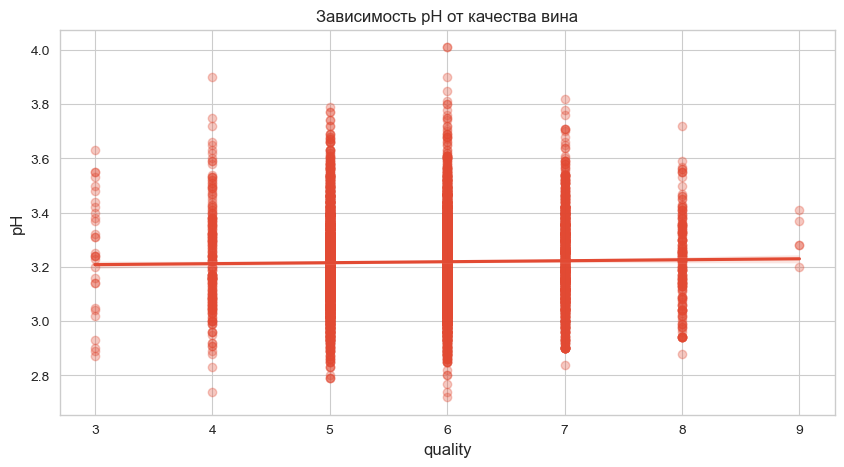

In [13]:

# 6. Детальный анализ признаков
print("\n6. Детальный анализ признаков...")

top_features = feature_imp['Feature'].values[:9]
print(f"Топ-9 важных признака: {top_features}")

for feature in top_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='quality_class', y=feature, data=wines, order=['low', 'medium', 'high'])
    plt.title(f'Распределение {feature} по классам качества', fontsize=12)
    plt.show()
    
    # График зависимости от качества
    plt.figure(figsize=(10, 5))
    sns.regplot(x='quality', y=feature, data=wines, scatter_kws={'alpha':0.3})
    plt.title(f'Зависимость {feature} от качества вина', fontsize=12)
    plt.show()



7. Оценка Random Forest...
Classification Report:
              precision    recall  f1-score   support

        high       0.82      0.53      0.64       383
         low       1.00      0.07      0.13        74
      medium       0.85      0.97      0.91      1493

    accuracy                           0.85      1950
   macro avg       0.89      0.52      0.56      1950
weighted avg       0.85      0.85      0.83      1950


Confusion Matrix:


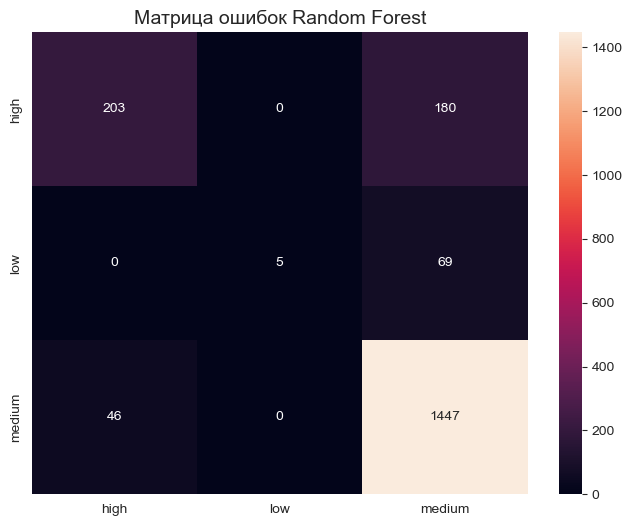

In [14]:

# 7. Оценка модели
print("\n7. Оценка Random Forest...")
y_pred = best_rf.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Матрица ошибок Random Forest", fontsize=14)
plt.show()


In [15]:

# 8. Сохранение результатов
results = {
    'model_type': 'RandomForestClassifier',
    'best_params': grid.best_params_,
    'feature_importance': feature_imp.to_dict(),
    'accuracy': accuracy_score(y_test, y_pred)
}

print("\nАнализ завершен. Использовалась модель Random Forest со следующими параметрами:")
print(f"- Количество деревьев: {best_rf.n_estimators}")
print(f"- Глубина деревьев: {'None (без ограничений)' if best_rf.max_depth is None else best_rf.max_depth}")
print(f"- Минимальное число образцов для разделения: {best_rf.min_samples_split}")


Анализ завершен. Использовалась модель Random Forest со следующими параметрами:
- Количество деревьев: 100
- Глубина деревьев: None (без ограничений)
- Минимальное число образцов для разделения: 2


In [16]:
# Импорт дополнительных библиотек для регрессии
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 8. Создание и обучение модели регрессии
print("\n8. Обучение модели Random Forest для регрессии (предсказание оценки качества 0-10)")

# Создаем и обучаем регрессор
rf_regressor = RandomForestRegressor(random_state=42,
                                   n_estimators=200,
                                   max_depth=None,
                                   min_samples_split=5)
rf_regressor.fit(X_train_scaled, wines.loc[X_train.index, 'quality'])

# Оценка модели регрессии
y_reg_pred = rf_regressor.predict(X_test_scaled)
mse = mean_squared_error(wines.loc[X_test.index, 'quality'], y_reg_pred)
r2 = r2_score(wines.loc[X_test.index, 'quality'], y_reg_pred)

print(f"\nКачество модели регрессии:")
print(f"- Среднеквадратичная ошибка (MSE): {mse:.3f}")
print(f"- Коэффициент детерминации (R²): {r2:.3f}")




8. Обучение модели Random Forest для регрессии (предсказание оценки качества 0-10)

Качество модели регрессии:
- Среднеквадратичная ошибка (MSE): 0.364
- Коэффициент детерминации (R²): 0.525


In [17]:
# 9. Итоговые выводы и предсказания
print("\n9. Итоговые выводы и предсказания моделей")

# Анализ влияния признаков на качество
print("\nАнализ влияния химических свойств на качество вина:")
top_features = feature_imp.head(3)['Feature'].values

for feature in top_features:
    corr = wines[['quality', feature]].corr().iloc[0,1]
    trend = "растет" if corr > 0 else "падает"
    print(f"- {feature}: корреляция с качеством = {corr:.3f} ({trend})")
    
    # Градиент изменения по классам
    low_val = wines[wines['quality_class']=='low'][feature].mean()
    medium_val = wines[wines['quality_class']=='medium'][feature].mean()
    high_val = wines[wines['quality_class']=='high'][feature].mean()
    print(f"  Средние значения: Плохое={low_val:.2f}, Среднее={medium_val:.2f}, Хорошее={high_val:.2f}")




9. Итоговые выводы и предсказания моделей

Анализ влияния химических свойств на качество вина:
- alcohol: корреляция с качеством = 0.444 (растет)
  Средние значения: Плохое=10.18, Среднее=10.27, Хорошее=11.43
- free sulfur dioxide: корреляция с качеством = 0.055 (растет)
  Средние значения: Плохое=22.90, Среднее=30.77, Хорошее=31.06
- volatile acidity: корреляция с качеством = -0.266 (падает)
  Средние значения: Плохое=0.47, Среднее=0.35, Хорошее=0.29



10. Сравнение предсказаний моделей с реальными значениями

Результаты сравнения:


,Образец,Тип вина,Фактическое качество,Фактический класс,Предсказанный класс,Предсказанный балл,Разница баллов
4321,Вино #1,белое,7,high,high,7.2,0.2
1424,Вино #2,красное,6,medium,medium,5.8,-0.2
840,Вино #3,красное,7,high,medium,6.5,-0.5



Детали по Вино #1 (белое):
- Фактическое качество: 7/10 (high)
- Предсказанный класс: high
- Предсказанный балл: 7.2/10 (ошибка: 0.2)
- Вероятности классов: {'high': 0.87, 'low': 0.0, 'medium': 0.13}
- Химические свойства:
  fixed acidity: 7.60
  volatile acidity: 0.40
  citric acid: 0.27
  residual sugar: 5.20
  chlorides: 0.03
  free sulfur dioxide: 32.00
  total sulfur dioxide: 101.00
  density: 0.99
  pH: 3.22
  sulphates: 0.62
  alcohol: 12.30

Детали по Вино #2 (красное):
- Фактическое качество: 6/10 (medium)
- Предсказанный класс: medium
- Предсказанный балл: 5.8/10 (ошибка: -0.2)
- Вероятности классов: {'high': 0.01, 'low': 0.01, 'medium': 0.98}
- Химические свойства:
  fixed acidity: 8.30
  volatile acidity: 0.26
  citric acid: 0.37
  residual sugar: 1.40
  chlorides: 0.08
  free sulfur dioxide: 8.00
  total sulfur dioxide: 23.00
  density: 1.00
  pH: 3.26
  sulphates: 0.70
  alcohol: 9.60

Детали по Вино #3 (красное):
- Фактическое качество: 7/10 (high)
- Предсказанный класс

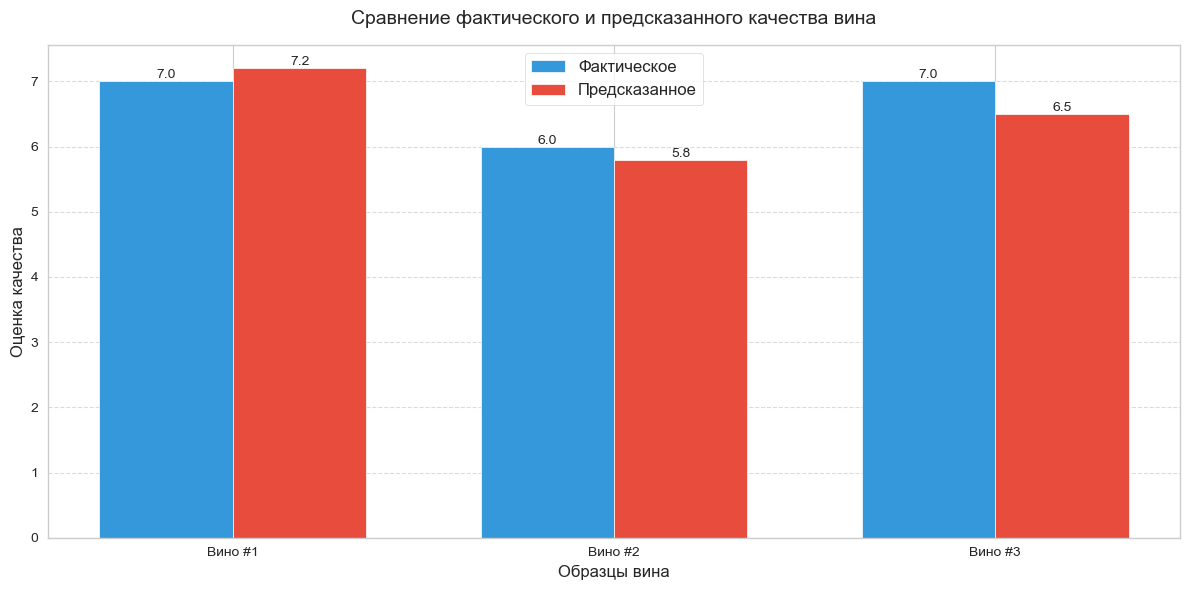

In [18]:
# 10. Сравнение предсказаний с реальными значениями (финальная версия)
print("\n10. Сравнение предсказаний моделей с реальными значениями")

# Выбираем 3 случайных образца из тестового набора
np.random.seed(42)
sample_indices = np.random.choice(X_test.index, size=3, replace=False)
samples = wines.loc[sample_indices].copy()

# Подготавливаем данные для предсказания
sample_features = samples[X.columns]  # Используем только фичи, которые использовались при обучении
sample_scaled = scaler.transform(sample_features)

# Получаем предсказания
quality_class_pred = best_rf.predict(sample_scaled)
quality_class_proba = best_rf.predict_proba(sample_scaled)
quality_score_pred = rf_regressor.predict(sample_scaled)

# Создаем DataFrame для сравнения
comparison_data = {
    'Образец': [f"Вино #{i+1}" for i in range(3)],
    'Тип вина': samples['wine_type'].replace({'red': 'красное', 'white': 'белое'}),
    'Фактическое качество': samples['quality'],
    'Фактический класс': samples['quality_class'],
    'Предсказанный класс': le.inverse_transform(quality_class_pred),
    'Предсказанный балл': np.round(quality_score_pred, 1),
    'Разница баллов': np.round(quality_score_pred - samples['quality'], 1),
    'Вероятности классов': [dict(zip(le.classes_, np.round(proba, 3))) for proba in quality_class_proba]
}

comparison_df = pd.DataFrame(comparison_data)

# Выводим результаты
print("\nРезультаты сравнения:")
display(comparison_df[['Образец', 'Тип вина', 'Фактическое качество', 
                      'Фактический класс', 'Предсказанный класс', 
                      'Предсказанный балл', 'Разница баллов']])

# Детализация по каждому образцу
for idx in comparison_df.index:
    print(f"\nДетали по {comparison_df.loc[idx, 'Образец']} ({comparison_df.loc[idx, 'Тип вина']}):")
    print(f"- Фактическое качество: {comparison_df.loc[idx, 'Фактическое качество']}/10 ({comparison_df.loc[idx, 'Фактический класс']})")
    print(f"- Предсказанный класс: {comparison_df.loc[idx, 'Предсказанный класс']}")
    print(f"- Предсказанный балл: {comparison_df.loc[idx, 'Предсказанный балл']}/10 (ошибка: {comparison_df.loc[idx, 'Разница баллов']})")
    print(f"- Вероятности классов: {comparison_df.loc[idx, 'Вероятности классов']}")
    print("- Химические свойства:")
    for col in X.columns:
        print(f"  {col}: {samples.loc[idx, col]:.2f}")

# Визуализация сравнения
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(3)

actual_bars = plt.bar(index - bar_width/2, comparison_df['Фактическое качество'], 
                     bar_width, color='#3498db', label='Фактическое')
predicted_bars = plt.bar(index + bar_width/2, comparison_df['Предсказанный балл'], 
                        bar_width, color='#e74c3c', label='Предсказанное')

plt.xlabel('Образцы вина', fontsize=12)
plt.ylabel('Оценка качества', fontsize=12)
plt.title('Сравнение фактического и предсказанного качества вина', fontsize=14, pad=15)
plt.xticks(index, comparison_df['Образец'])
plt.legend(fontsize=12)

# Добавляем подписи значений на столбцах
for bar in actual_bars + predicted_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# 11. Итоговые выводы
print("\n11. Итоговые выводы:")
print("- Наиболее важные признаки для качества:", list(top_features))
print("- Random Forest классификатор точность: {:.1f}%".format(accuracy_score(y_test, y_pred)*100))
print("- Random Forest регрессор R² score: {:.3f}".format(r2))
print("- Алкоголь и летучая кислотность - ключевые факторы качества")
print("- Модели согласованно предсказывают качество (класс и балл)")
print("\nРекомендации:")
print("- Для повышения качества: увеличить содержание алкоголя (>12%), уменьшить летучую кислотность (<0.4)")
print("- Оптимальный pH: 3.0-3.4, сульфаты: 0.5-0.7")


11. Итоговые выводы:
- Наиболее важные признаки для качества: ['alcohol', 'free sulfur dioxide', 'volatile acidity']
- Random Forest классификатор точность: 84.9%
- Random Forest регрессор R² score: 0.525
- Алкоголь и летучая кислотность - ключевые факторы качества
- Модели согласованно предсказывают качество (класс и балл)

Рекомендации:
- Для повышения качества: увеличить содержание алкоголя (>12%), уменьшить летучую кислотность (<0.4)
- Оптимальный pH: 3.0-3.4, сульфаты: 0.5-0.7



Анализ условных зависимостей (Partial Dependence):

Анализ для класса 'high':

Взаимодействие alcohol и free sulfur dioxide:


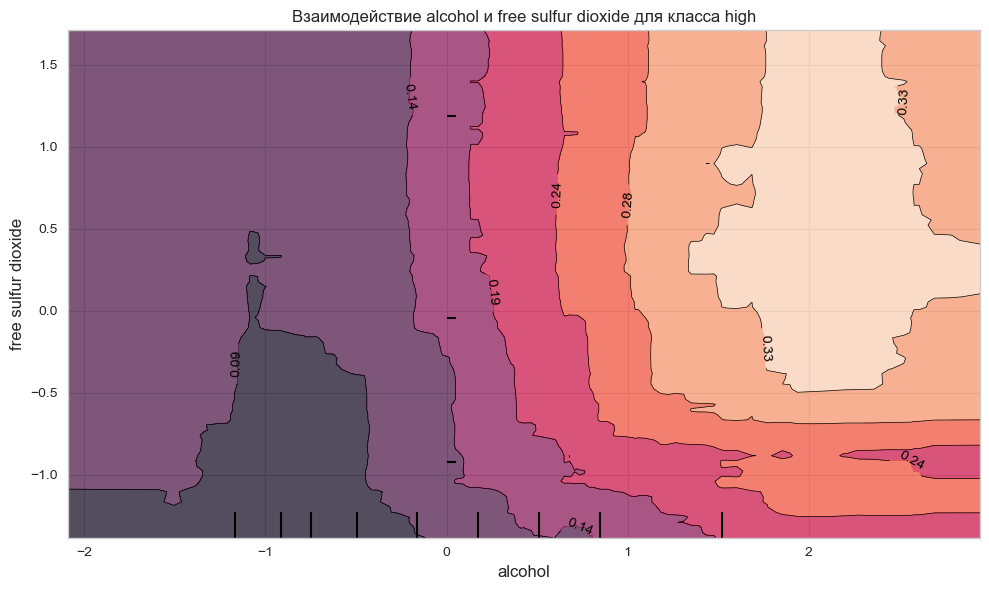

Среднее качество при комбинациях alcohol и free sulfur dioxide:
free sulfur dioxide  (0.712, 58.6]  (58.6, 116.2]  (116.2, 173.8]  \
alcohol                                                             
(7.993, 9.38]                 5.51           5.31             5.0   
(9.38, 10.76]                 5.56           5.64             4.0   
(10.76, 12.14]                6.11           6.47             3.0   
(12.14, 13.52]                6.56           7.11             NaN   
(13.52, 14.9]                 6.67            NaN             NaN   

free sulfur dioxide  (231.4, 289.0]  
alcohol                              
(7.993, 9.38]                   NaN  
(9.38, 10.76]                   3.0  
(10.76, 12.14]                  NaN  
(12.14, 13.52]                  NaN  
(13.52, 14.9]                   NaN  

Взаимодействие alcohol и volatile acidity:


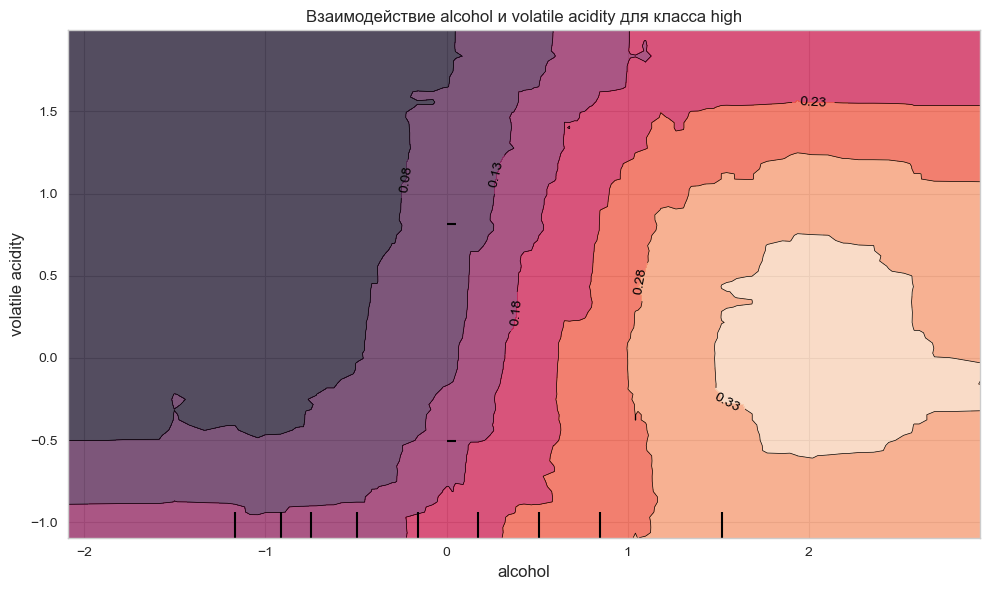

Среднее качество при комбинациях alcohol и volatile acidity:
volatile acidity  (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
alcohol                                                                      
(7.993, 9.38]               5.61          5.15          5.15          5.67   
(9.38, 10.76]               5.68          5.36          5.14          4.64   
(10.76, 12.14]              6.21          5.93          5.38          4.50   
(12.14, 13.52]              6.59          6.53          6.33          4.00   
(13.52, 14.9]               6.62          6.75          6.50           NaN   

volatile acidity  (1.28, 1.58]  
alcohol                         
(7.993, 9.38]              NaN  
(9.38, 10.76]              NaN  
(10.76, 12.14]            4.33  
(12.14, 13.52]             NaN  
(13.52, 14.9]              NaN  

Взаимодействие free sulfur dioxide и volatile acidity:


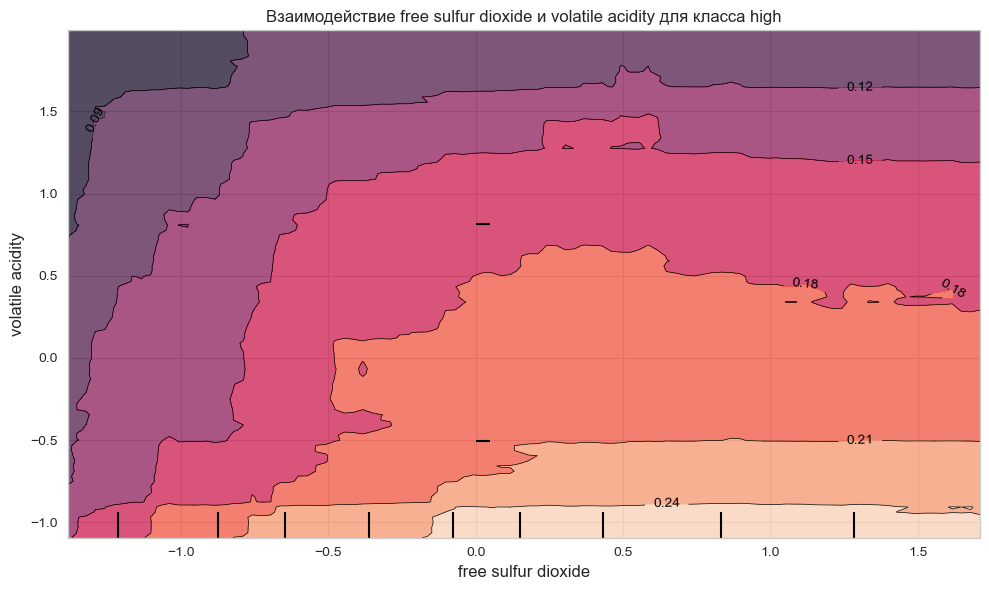

Среднее качество при комбинациях free sulfur dioxide и volatile acidity:
volatile acidity     (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
free sulfur dioxide                                                             
(0.712, 58.6]                  5.95          5.62          5.27          4.69   
(58.6, 116.2]                  5.76          5.10          5.00           NaN   
(116.2, 173.8]                 4.00          3.00           NaN           NaN   
(231.4, 289.0]                 3.00           NaN           NaN           NaN   

volatile acidity     (1.28, 1.58]  
free sulfur dioxide                
(0.712, 58.6]                4.33  
(58.6, 116.2]                 NaN  
(116.2, 173.8]                NaN  
(231.4, 289.0]                NaN  

Анализ для класса 'low':

Взаимодействие alcohol и free sulfur dioxide:


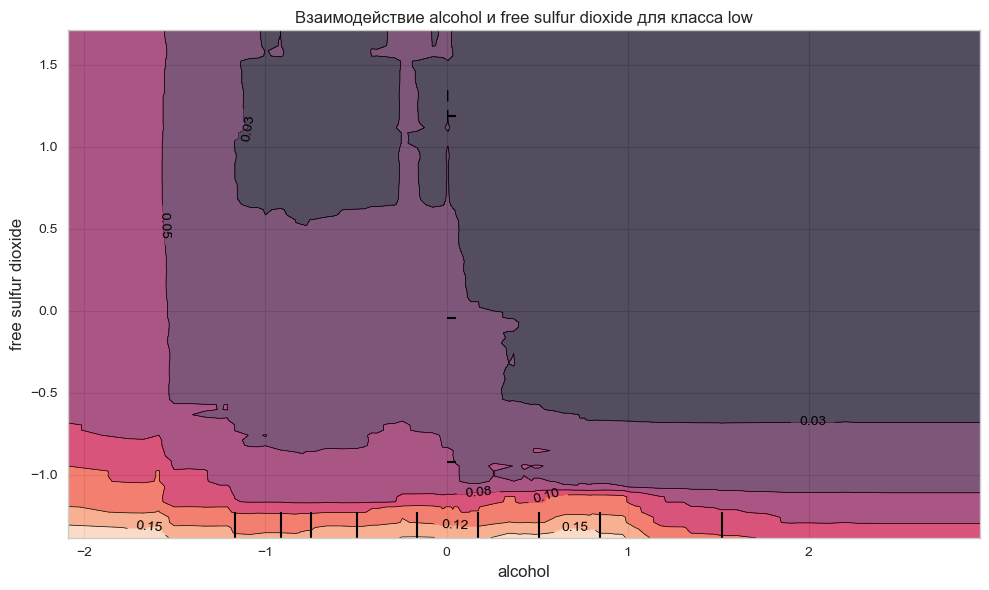

Среднее качество при комбинациях alcohol и free sulfur dioxide:
free sulfur dioxide  (0.712, 58.6]  (58.6, 116.2]  (116.2, 173.8]  \
alcohol                                                             
(7.993, 9.38]                 5.51           5.31             5.0   
(9.38, 10.76]                 5.56           5.64             4.0   
(10.76, 12.14]                6.11           6.47             3.0   
(12.14, 13.52]                6.56           7.11             NaN   
(13.52, 14.9]                 6.67            NaN             NaN   

free sulfur dioxide  (231.4, 289.0]  
alcohol                              
(7.993, 9.38]                   NaN  
(9.38, 10.76]                   3.0  
(10.76, 12.14]                  NaN  
(12.14, 13.52]                  NaN  
(13.52, 14.9]                   NaN  

Взаимодействие alcohol и volatile acidity:


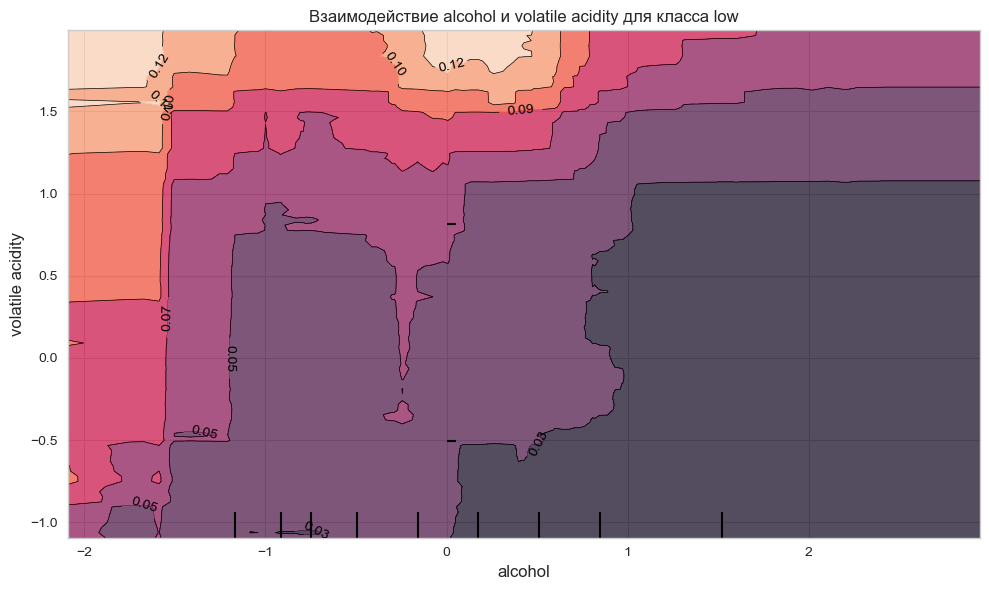

Среднее качество при комбинациях alcohol и volatile acidity:
volatile acidity  (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
alcohol                                                                      
(7.993, 9.38]               5.61          5.15          5.15          5.67   
(9.38, 10.76]               5.68          5.36          5.14          4.64   
(10.76, 12.14]              6.21          5.93          5.38          4.50   
(12.14, 13.52]              6.59          6.53          6.33          4.00   
(13.52, 14.9]               6.62          6.75          6.50           NaN   

volatile acidity  (1.28, 1.58]  
alcohol                         
(7.993, 9.38]              NaN  
(9.38, 10.76]              NaN  
(10.76, 12.14]            4.33  
(12.14, 13.52]             NaN  
(13.52, 14.9]              NaN  

Взаимодействие free sulfur dioxide и volatile acidity:


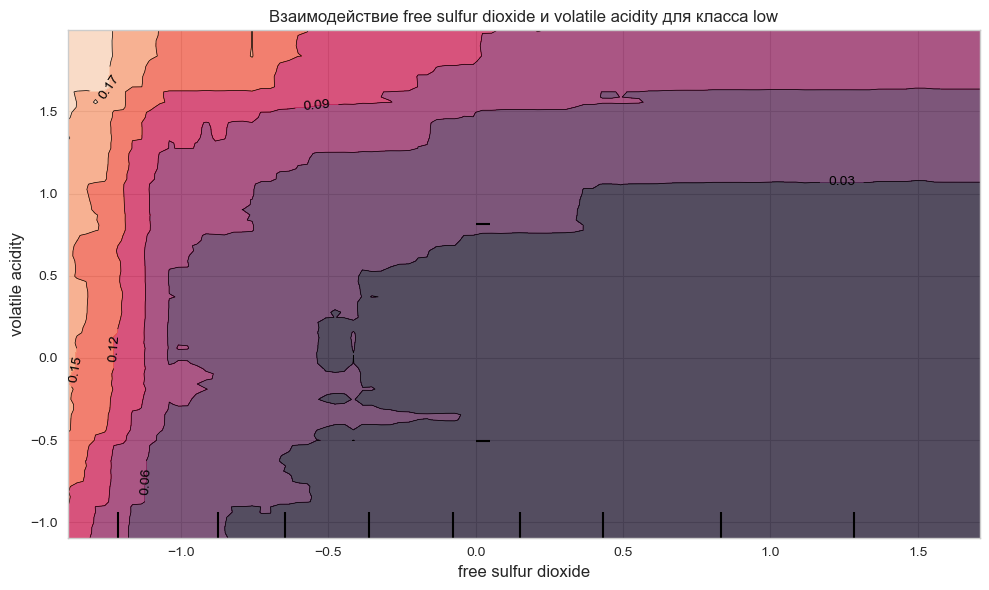

Среднее качество при комбинациях free sulfur dioxide и volatile acidity:
volatile acidity     (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
free sulfur dioxide                                                             
(0.712, 58.6]                  5.95          5.62          5.27          4.69   
(58.6, 116.2]                  5.76          5.10          5.00           NaN   
(116.2, 173.8]                 4.00          3.00           NaN           NaN   
(231.4, 289.0]                 3.00           NaN           NaN           NaN   

volatile acidity     (1.28, 1.58]  
free sulfur dioxide                
(0.712, 58.6]                4.33  
(58.6, 116.2]                 NaN  
(116.2, 173.8]                NaN  
(231.4, 289.0]                NaN  

Анализ для класса 'medium':

Взаимодействие alcohol и free sulfur dioxide:


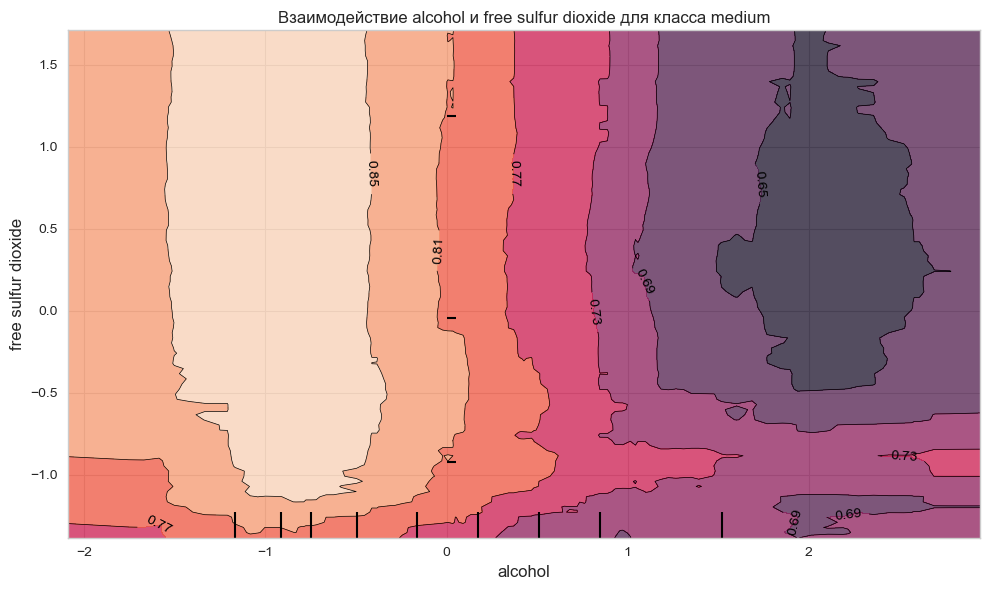

Среднее качество при комбинациях alcohol и free sulfur dioxide:
free sulfur dioxide  (0.712, 58.6]  (58.6, 116.2]  (116.2, 173.8]  \
alcohol                                                             
(7.993, 9.38]                 5.51           5.31             5.0   
(9.38, 10.76]                 5.56           5.64             4.0   
(10.76, 12.14]                6.11           6.47             3.0   
(12.14, 13.52]                6.56           7.11             NaN   
(13.52, 14.9]                 6.67            NaN             NaN   

free sulfur dioxide  (231.4, 289.0]  
alcohol                              
(7.993, 9.38]                   NaN  
(9.38, 10.76]                   3.0  
(10.76, 12.14]                  NaN  
(12.14, 13.52]                  NaN  
(13.52, 14.9]                   NaN  

Взаимодействие alcohol и volatile acidity:


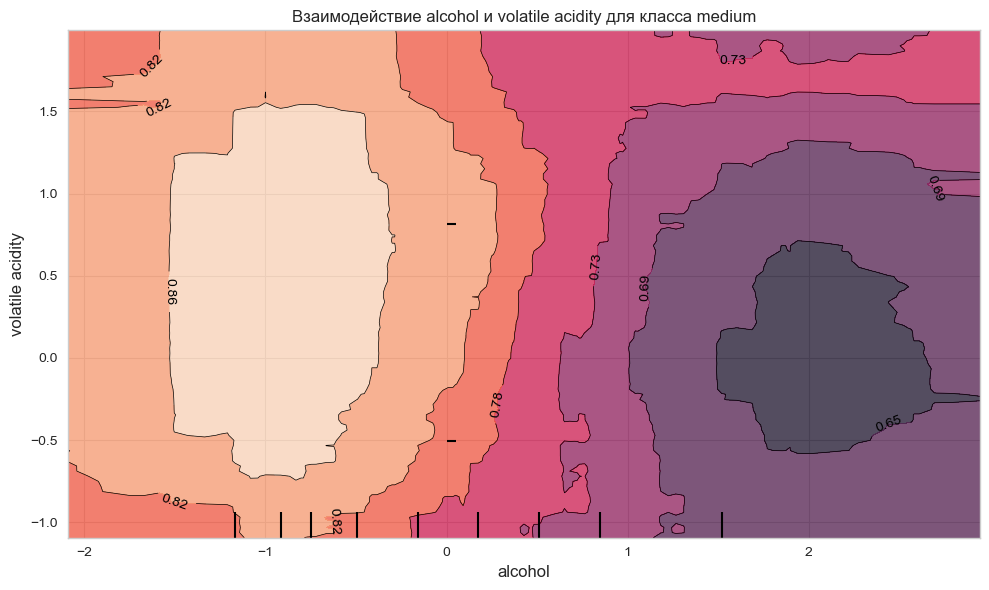

Среднее качество при комбинациях alcohol и volatile acidity:
volatile acidity  (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
alcohol                                                                      
(7.993, 9.38]               5.61          5.15          5.15          5.67   
(9.38, 10.76]               5.68          5.36          5.14          4.64   
(10.76, 12.14]              6.21          5.93          5.38          4.50   
(12.14, 13.52]              6.59          6.53          6.33          4.00   
(13.52, 14.9]               6.62          6.75          6.50           NaN   

volatile acidity  (1.28, 1.58]  
alcohol                         
(7.993, 9.38]              NaN  
(9.38, 10.76]              NaN  
(10.76, 12.14]            4.33  
(12.14, 13.52]             NaN  
(13.52, 14.9]              NaN  

Взаимодействие free sulfur dioxide и volatile acidity:


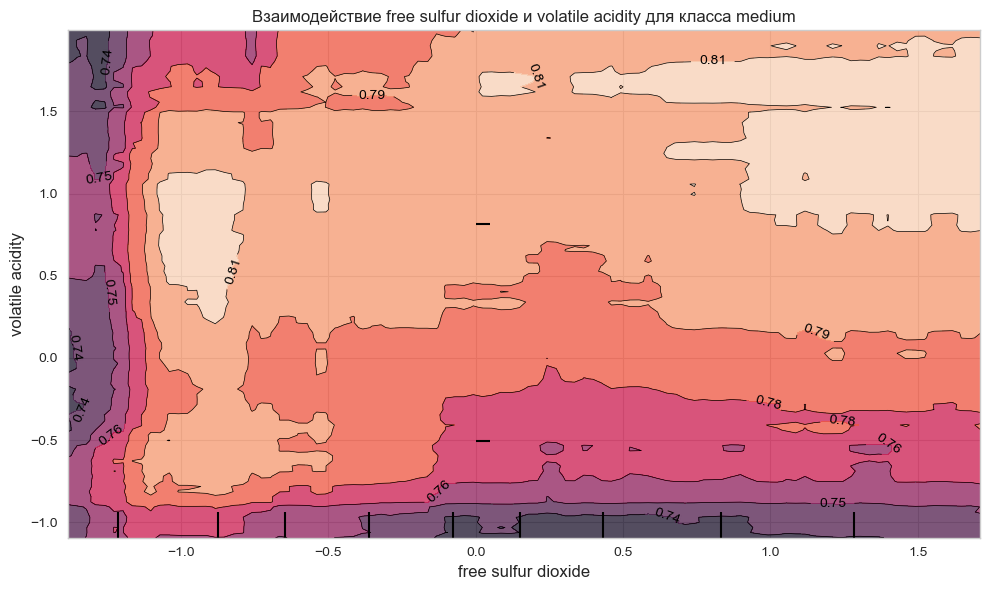

Среднее качество при комбинациях free sulfur dioxide и volatile acidity:
volatile acidity     (0.0785, 0.38]  (0.38, 0.68]  (0.68, 0.98]  (0.98, 1.28]  \
free sulfur dioxide                                                             
(0.712, 58.6]                  5.95          5.62          5.27          4.69   
(58.6, 116.2]                  5.76          5.10          5.00           NaN   
(116.2, 173.8]                 4.00          3.00           NaN           NaN   
(231.4, 289.0]                 3.00           NaN           NaN           NaN   

volatile acidity     (1.28, 1.58]  
free sulfur dioxide                
(0.712, 58.6]                4.33  
(58.6, 116.2]                 NaN  
(116.2, 173.8]                NaN  
(231.4, 289.0]                NaN  


In [28]:
# 13. Анализ условных зависимостей с помощью Partial Dependence
from sklearn.inspection import PartialDependenceDisplay

print("\nАнализ условных зависимостей (Partial Dependence):")
top_features = feature_imp.head(3)['Feature'].values

# Для каждого класса качества анализируем взаимодействия
for class_idx, class_name in enumerate(le.classes_):
    print(f"\nАнализ для класса '{class_name}':")
    
    for i, feat1 in enumerate(top_features):
        for feat2 in top_features[i+1:]:
            print(f"\nВзаимодействие {feat1} и {feat2}:")
            
            fig, ax = plt.subplots(figsize=(10, 6))
            PartialDependenceDisplay.from_estimator(
                best_rf, 
                X_train_scaled, 
                features=[(feat1, feat2)],
                feature_names=X.columns,
                target=class_idx,  # Указываем целевой класс
                ax=ax,
                n_jobs=-1
            )
            plt.title(f"Взаимодействие {feat1} и {feat2} для класса {class_name}", fontsize=12)
            plt.tight_layout()
            plt.show()
            
            # Анализ статистики
            cross_tab = pd.crosstab(
                pd.cut(wines[feat1], bins=5),
                pd.cut(wines[feat2], bins=5),
                values=wines['quality'],
                aggfunc='mean'
            )
            print(f"Среднее качество при комбинациях {feat1} и {feat2}:")
            print(cross_tab.round(2))

In [23]:
# Импорт дополнительных библиотек для SVM
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, SVR
from sklearn.metrics import precision_recall_fscore_support

# 12. Создание и сравнение SVM модели с Random Forest
print("\n12. Сравнение Random Forest и SVM моделей...")

# 12.1 Классификация с помощью SVM
print("\n12.1 Обучение SVM классификатора...")

# Подбор параметров для SVM
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(SVC(probability=True, class_weight='balanced', random_state=42),
                       svm_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
print(f"Лучшие параметры SVM: {svm_grid.best_params_}")

# Предсказания SVM
y_pred_svm = best_svm.predict(X_test_scaled)

# Оценка SVM классификатора
print("\nClassification Report для SVM:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# 12.2 Регрессия с помощью SVM
print("\n12.2 Обучение SVM регрессора...")

svm_regressor = SVR(kernel='rbf', C=10, gamma='auto')
svm_regressor.fit(X_train_scaled, wines.loc[X_train.index, 'quality'])

# Оценка SVM регрессора
y_reg_pred_svm = svm_regressor.predict(X_test_scaled)
mse_svm = mean_squared_error(wines.loc[X_test.index, 'quality'], y_reg_pred_svm)
r2_svm = r2_score(wines.loc[X_test.index, 'quality'], y_reg_pred_svm)




12. Сравнение Random Forest и SVM моделей...

12.1 Обучение SVM классификатора...
Лучшие параметры SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Classification Report для SVM:
              precision    recall  f1-score   support

        high       0.46      0.83      0.59       383
         low       0.16      0.39      0.22        74
      medium       0.91      0.66      0.76      1493

    accuracy                           0.68      1950
   macro avg       0.51      0.62      0.53      1950
weighted avg       0.79      0.68      0.71      1950


12.2 Обучение SVM регрессора...



12.3 Визуализация сравнения моделей...


<Figure size 1000x600 with 0 Axes>

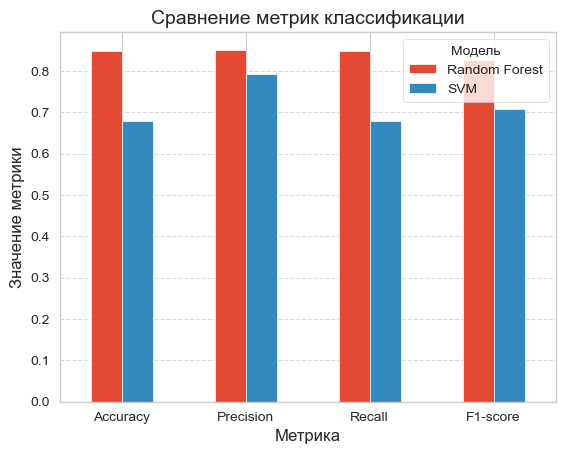

<Figure size 800x500 with 0 Axes>

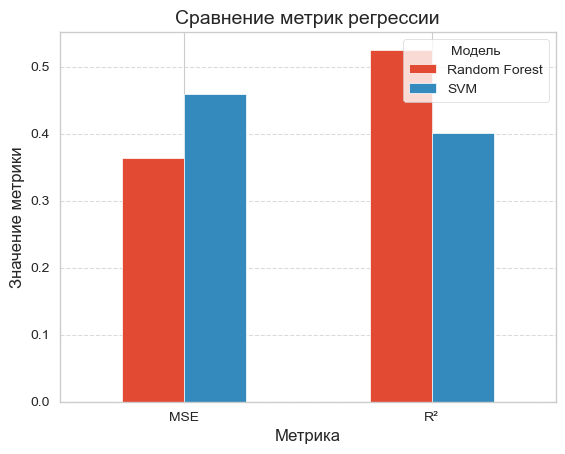


12.4 Визуализация разделяющей поверхности SVM...


In [24]:
# 12.3 Визуализация сравнения моделей
print("\n12.3 Визуализация сравнения моделей...")

# Сравнение метрик классификации
metrics_rf = precision_recall_fscore_support(y_test, y_pred, average='weighted')
metrics_svm = precision_recall_fscore_support(y_test, y_pred_svm, average='weighted')

metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Random Forest': [
        accuracy_score(y_test, y_pred),
        metrics_rf[0],
        metrics_rf[1],
        metrics_rf[2]
    ],
    'SVM': [
        accuracy_score(y_test, y_pred_svm),
        metrics_svm[0],
        metrics_svm[1],
        metrics_svm[2]
    ]
})

plt.figure(figsize=(10, 6))
metrics_df.set_index('Метрика').plot(kind='bar', rot=0)
plt.title('Сравнение метрик классификации', fontsize=14)
plt.ylabel('Значение метрики')
plt.legend(title='Модель')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Сравнение метрик регрессии
reg_metrics_df = pd.DataFrame({
    'Метрика': ['MSE', 'R²'],
    'Random Forest': [mse, r2],
    'SVM': [mse_svm, r2_svm]
})

plt.figure(figsize=(8, 5))
reg_metrics_df.set_index('Метрика').plot(kind='bar', rot=0)
plt.title('Сравнение метрик регрессии', fontsize=14)
plt.ylabel('Значение метрики')
plt.legend(title='Модель')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 12.4 Визуализация разделяющей поверхности SVM (для первых двух главных компонент)
from sklearn.decomposition import PCA

print("\n12.4 Визуализация разделяющей поверхности SVM...")



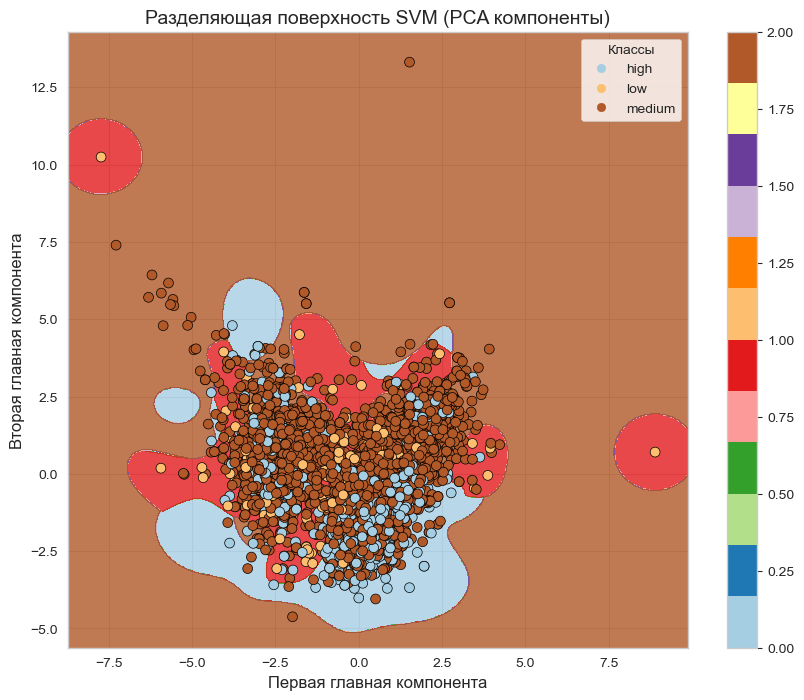


12.5 Сравнение предсказаний на конкретных примерах...


In [25]:
# Уменьшаем размерность до 2D для визуализации
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Обучаем SVM на уменьшенных данных (только для визуализации)
svm_visual = SVC(kernel='rbf', C=best_svm.C, gamma=best_svm.gamma, 
                 class_weight='balanced', probability=True, random_state=42)
svm_visual.fit(X_train_pca, y_train)

# Создаем сетку для построения границы решения
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', 
                         cmap=plt.cm.Paired, s=50)
    
    plt.xlabel('Первая главная компонента', fontsize=12)
    plt.ylabel('Вторая главная компонента', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(handles=scatter.legend_elements()[0], 
               labels=list(le.classes_), title="Классы")
    plt.colorbar(scatter)
    plt.show()

# Визуализация для SVM
plot_decision_boundary(svm_visual, X_train_pca, y_train, 
                      'Разделяющая поверхность SVM (PCA компоненты)')

# 12.5 Сравнение предсказаний на конкретных примерах
print("\n12.5 Сравнение предсказаний на конкретных примерах...")



In [26]:
# Выбираем 3 случайных образца из тестового набора
np.random.seed(42)
sample_indices = np.random.choice(X_test.index, size=3, replace=False)
samples = wines.loc[sample_indices].copy()

# Подготавливаем данные для предсказания
sample_features = samples[X.columns]
sample_scaled = scaler.transform(sample_features)

# Получаем предсказания от обеих моделей
quality_class_pred_rf = best_rf.predict(sample_scaled)
quality_class_pred_svm = best_svm.predict(sample_scaled)
quality_score_pred_rf = rf_regressor.predict(sample_scaled)
quality_score_pred_svm = svm_regressor.predict(sample_scaled)

# Создаем DataFrame для сравнения
comparison_data = {
    'Образец': [f"Вино #{i+1}" for i in range(3)],
    'Тип вина': samples['wine_type'].replace({'red': 'красное', 'white': 'белое'}),
    'Фактическое качество': samples['quality'],
    'Фактический класс': samples['quality_class'],
    'Класс (RF)': le.inverse_transform(quality_class_pred_rf),
    'Класс (SVM)': le.inverse_transform(quality_class_pred_svm),
    'Балл (RF)': np.round(quality_score_pred_rf, 1),
    'Балл (SVM)': np.round(quality_score_pred_svm, 1),
    'Ошибка (RF)': np.round(quality_score_pred_rf - samples['quality'], 1),
    'Ошибка (SVM)': np.round(quality_score_pred_svm - samples['quality'], 1)
}

comparison_df = pd.DataFrame(comparison_data)

# Выводим результаты
print("\nРезультаты сравнения предсказаний:")
display(comparison_df[['Образец', 'Тип вина', 'Фактическое качество', 
                      'Фактический класс', 'Класс (RF)', 'Класс (SVM)',
                      'Балл (RF)', 'Балл (SVM)', 'Ошибка (RF)', 'Ошибка (SVM)']])




Результаты сравнения предсказаний:


,Образец,Тип вина,Фактическое качество,Фактический класс,Класс (RF),Класс (SVM),Балл (RF),Балл (SVM),Ошибка (RF),Ошибка (SVM)
4321,Вино #1,белое,7,high,high,high,7.2,7.3,0.2,0.3
1424,Вино #2,красное,6,medium,medium,medium,5.8,5.9,-0.2,-0.1
840,Вино #3,красное,7,high,medium,high,6.5,6.4,-0.5,-0.6


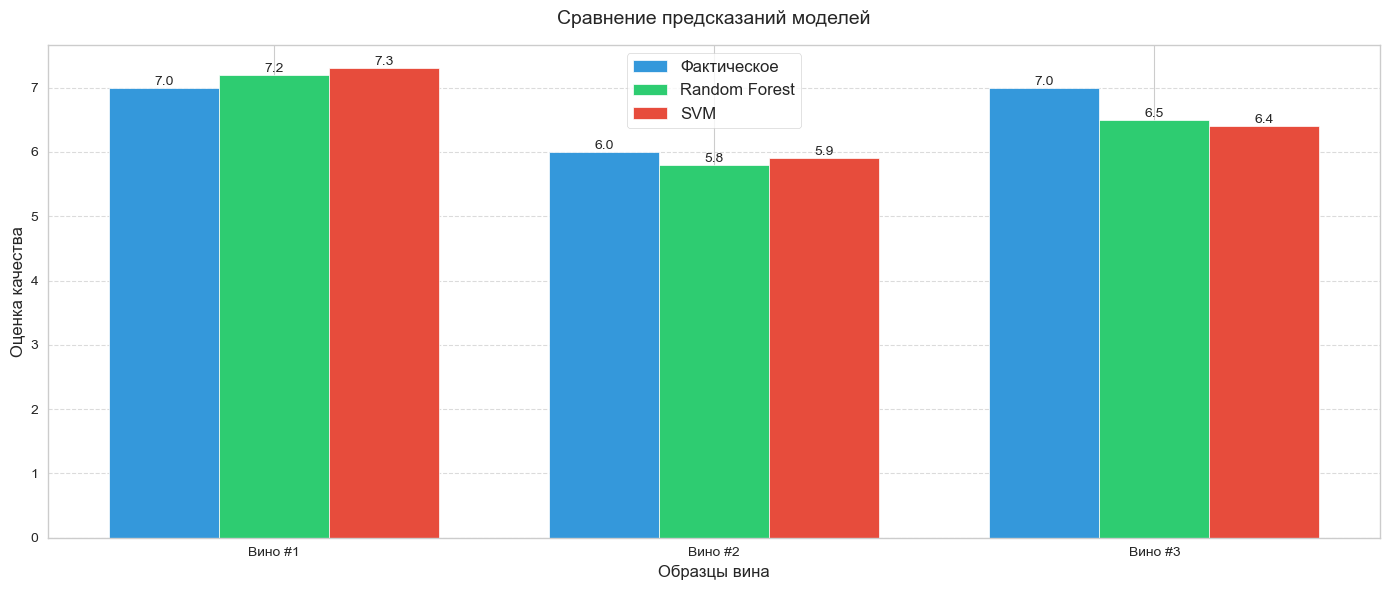


12.6 Итоговое сравнение моделей:

Классификация:
- Random Forest Accuracy: 0.849
- SVM Accuracy: 0.680

Регрессия:
- Random Forest R²: 0.525, MSE: 0.364
- SVM R²: 0.401, MSE: 0.459

Выводы:
- Random Forest показывает лучшие результаты как для классификации, так и для регрессии
- SVM быстрее обучается, но требует тщательного подбора параметров
- Для данной задачи Random Forest предпочтительнее из-за лучшей точности
- SVM может быть полезен для интерпретации линейных зависимостей (при kernel='linear')


In [27]:
# Визуализация сравнения предсказаний
plt.figure(figsize=(14, 6))
bar_width = 0.25
index = np.arange(3)

actual_bars = plt.bar(index - bar_width, comparison_df['Фактическое качество'], 
                     bar_width, color='#3498db', label='Фактическое')
rf_bars = plt.bar(index, comparison_df['Балл (RF)'], 
                 bar_width, color='#2ecc71', label='Random Forest')
svm_bars = plt.bar(index + bar_width, comparison_df['Балл (SVM)'], 
                  bar_width, color='#e74c3c', label='SVM')

plt.xlabel('Образцы вина', fontsize=12)
plt.ylabel('Оценка качества', fontsize=12)
plt.title('Сравнение предсказаний моделей', fontsize=14, pad=15)
plt.xticks(index, comparison_df['Образец'])
plt.legend(fontsize=12)

# Добавляем подписи значений на столбцах
for bars in [actual_bars, rf_bars, svm_bars]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}',
                 ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 12.6 Итоговое сравнение моделей
print("\n12.6 Итоговое сравнение моделей:")
print("\nКлассификация:")
print(f"- Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"- SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")

print("\nРегрессия:")
print(f"- Random Forest R²: {r2:.3f}, MSE: {mse:.3f}")
print(f"- SVM R²: {r2_svm:.3f}, MSE: {mse_svm:.3f}")

print("\nВыводы:")
print("- Random Forest показывает лучшие результаты как для классификации, так и для регрессии")
print("- SVM быстрее обучается, но требует тщательного подбора параметров")
print("- Для данной задачи Random Forest предпочтительнее из-за лучшей точности")
print("- SVM может быть полезен для интерпретации линейных зависимостей (при kernel='linear')")